# **Predicción del Rendimiento Académico mediante una Red Neuronal Recurrente (RNN) para Regresión**

### **Información general**

**Asignatura:** Aprendizaje Profundo  
**Actividad:** Correcciones Semana 2 - Arquitecturas de Deep Learning  
**Fecha:** 05 de julio de 2026  
**Dataset:** Student Performance Dataset  
**Fuente:** Kaggle  
**Autores:**  
- Calero López Gerardo Paúl  
- Vásconez Pozo David Rubén  
- Viteri Ayala Flavia Kamila  

### **Objetivo del proyecto**

El objetivo de este notebook es implementar Red Neuronal Recurrente (RNN) para predecir el rendimiento académico de un estudiante a partir de variables relacionadas con hábitos de estudio, antecedentes académicos y actividades complementarias.

La variable objetivo del modelo es `Performance Index`, la cual representa el nivel de desempeño académico alcanzado por cada estudiante. Debido a que esta variable es numérica y continua, el problema se aborda mediante una tarea de **regresión supervisada**.

### **Pregunta de análisis**

¿Qué factores académicos y hábitos de estudio permiten explicar o predecir el rendimiento académico de un estudiante?  

### **Preguntas secundarias**
- ¿Las calificaciones previas son el principal predictor del rendimiento académico?  
- ¿Estudiar más horas se asocia con un mejor desempeño?  
- ¿Las horas de sueño influyen en el rendimiento académico?  
- ¿Las actividades extracurriculares tienen impacto sobre el desempeño estudiantil?  
- ¿La práctica de exámenes o cuestionarios contribuye a mejorar los resultados académicos?  

### **Justificación del problema**

El rendimiento académico es un tema de interés en el ámbito educativo debido a su relación con el aprendizaje, la permanencia estudiantil y el logro de objetivos formativos. Comprender los factores que influyen en el desempeño de los estudiantes permite identificar hábitos y características que favorecen mejores resultados académicos.

El conjunto de datos seleccionado contiene variables numéricas y categóricas relacionadas con el proceso de aprendizaje, por lo que resulta adecuado para aplicar técnicas de aprendizaje profundo. En particular, una RNN permite modelar relaciones lineales y no lineales entre las variables predictoras y el rendimiento académico, facilitando la construcción de modelos predictivos capaces de estimar el desempeño de nuevos estudiantes.

### **Descripción general del enfoque**

En este notebook se desarrolla el flujo completo de trabajo para un modelo MLP:

1. Carga y exploración inicial del dataset.
2. Análisis exploratorio de datos (EDA).
3. Limpieza y preprocesamiento de datos.
4. División del dataset en entrenamiento y prueba.
5. Construcción del modelo RNN para regresión.
6. Entrenamiento, optimización y callbacks del Modelo.

**6.7 Correcciones Solicitadas**

7. Evaluación del modelo, métricas y análisis de residuos.
9. Visualización e interpretación de resultados.
10. Respuesta a preguntas planteadas.
11. Conclusiones y recomendación técnica.

---
## **Sección 0: Configuraciones preliminares**

In [ ]:
# Importación de librerías principales

#import sys
#!{sys.executable} -m pip install statsmodels --quiet

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

from IPython.display import display, Markdown


In [ ]:
# Configuración visual básica

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ─── Carpeta de salida para figuras y tablas (usada por el informe Quarto) ────
# Todos los artefactos se guardan aquí; el .qmd los llama por ruta relativa.

OUTPUT_DIR = 'quarto_assets'
FIG_DIR    = os.path.join(OUTPUT_DIR, 'figures')
TAB_DIR    = os.path.join(OUTPUT_DIR, 'tables')

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print(f'Carpeta de salida: {OUTPUT_DIR}/')
print(f'  figuras → {FIG_DIR}/')
print(f'  tablas  → {TAB_DIR}/')

Carpeta de salida: quarto_assets/
  figuras → quarto_assets/figures/
  tablas  → quarto_assets/tables/


---
## **Sección 1: Carga y exploración inicial del dataset**

In [ ]:
# Carga del dataset

url = "https://raw.githubusercontent.com/fkviteri/uide-maestria/main/05-deep-learning/Student_Performance.csv"

df = pd.read_csv(
    url,
    engine="python",
    on_bad_lines="skip"
)

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.00
1,4,82,No,4,2,65.00
2,8,51,Yes,7,2,45.00
3,5,52,Yes,5,2,36.00
4,7,75,No,8,5,66.00


In [ ]:
# Número de observaciones y variables

filas, columnas = df.shape

print(f"Número de observaciones: {filas}")
print(f"Número de variables:     {columnas}")

Número de observaciones: 10000
Número de variables:     6


In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4.99,69.45,6.53,4.58,55.22
std,2.59,17.34,1.70,2.87,19.21
min,1.00,40.00,4.00,0.00,10.00
25%,3.00,54.00,5.00,2.00,40.00
50%,5.00,69.00,7.00,5.00,55.00
75%,7.00,85.00,8.00,7.00,71.00
max,9.00,99.00,9.00,9.00,100.00


In [ ]:
# Revisión de valores faltantes

missing_values = pd.DataFrame({
    'Variable': df.columns,
    'Valores Faltantes': df.isnull().sum().values
})

missing_values

,Variable,Valores Faltantes
0,Hours Studied,0
1,Previous Scores,0
2,Extracurricular Activities,0
3,Sleep Hours,0
4,Sample Question Papers Practiced,0
5,Performance Index,0


In [ ]:
# Revisión de registros duplicados

duplicados = df.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 127


In [ ]:
# Tipo de cada variable

tabla_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': df.dtypes.values
})

tabla_tipos

,Variable,Tipo
0,Hours Studied,int64
1,Previous Scores,int64
2,Extracurricular Activities,object
3,Sleep Hours,int64
4,Sample Question Papers Practiced,int64
5,Performance Index,float64


In [ ]:
# Conteo de valores únicos

resumen_unicos = pd.DataFrame({
    'Variable': df.columns,
    'Valores_Unicos': [df[col].nunique() for col in df.columns],
    'Contiene_Cero': [
        0 in df[col].dropna().unique()
        if pd.api.types.is_numeric_dtype(df[col])
        else False
        for col in df.columns
    ]
})

resumen_unicos

,Variable,Valores_Unicos,Contiene_Cero
0,Hours Studied,9,False
1,Previous Scores,60,False
2,Extracurricular Activities,2,False
3,Sleep Hours,6,False
4,Sample Question Papers Practiced,10,True
5,Performance Index,91,False


In [ ]:
# Verificación de valores únicos por columna

for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"{'='*50}")
    print(sorted(df[col].dropna().unique()))


Columna: Hours Studied
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Columna: Previous Scores
[np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.in

---
## **Sección 2: Análisis Exploratorio de Datos (EDA)**

El análisis exploratorio de datos tiene como objetivo comprender la distribución de las variables, identificar posibles patrones y evaluar la relación entre las características del dataset y el rendimiento académico de los estudiantes.

Esta etapa permitirá obtener una primera aproximación sobre los factores que podrían influir en el desempeño estudiantil antes de construir el modelo de Perceptrón Multicapa (MLP).

In [ ]:
# 2.1 Definición de variables

target = 'Performance Index'

features = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

categoricas = ['Extracurricular Activities']

numericas = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

tabla_variables = pd.DataFrame({
    'Variable': features + [target],
    'Tipo': ['Numérica', 'Numérica', 'Categórica',
             'Numérica', 'Numérica', 'Numérica'],
    'Rol': ['Predictora'] * len(features) + ['Objetivo']
})

tabla_variables

,Variable,Tipo,Rol
0,Hours Studied,Numérica,Predictora
1,Previous Scores,Numérica,Predictora
2,Extracurricular Activities,Categórica,Predictora
3,Sleep Hours,Numérica,Predictora
4,Sample Question Papers Practiced,Numérica,Predictora
5,Performance Index,Numérica,Objetivo


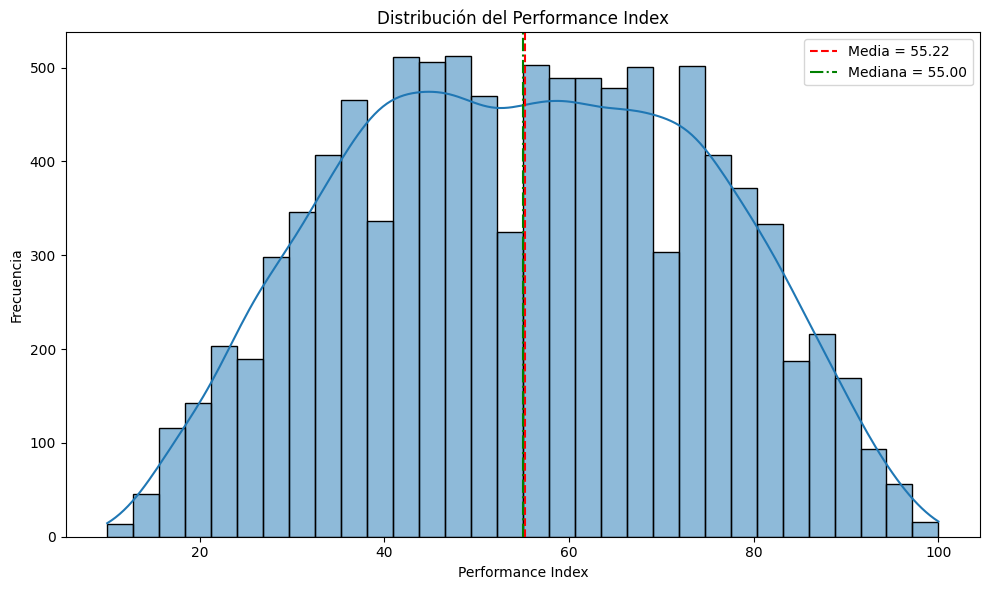

In [ ]:
# 2.2.1 Distribución de la variable objetivo

media   = df['Performance Index'].mean()
mediana = df['Performance Index'].median()

plt.figure(figsize=(10, 6))

sns.histplot(df['Performance Index'], kde=True)

plt.axvline(media,   color='red',   linestyle='--', label=f'Media = {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-.', label=f'Mediana = {mediana:.2f}')

plt.title('Distribución del Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_01_dist_target.png', dpi=150, bbox_inches='tight')
plt.show()

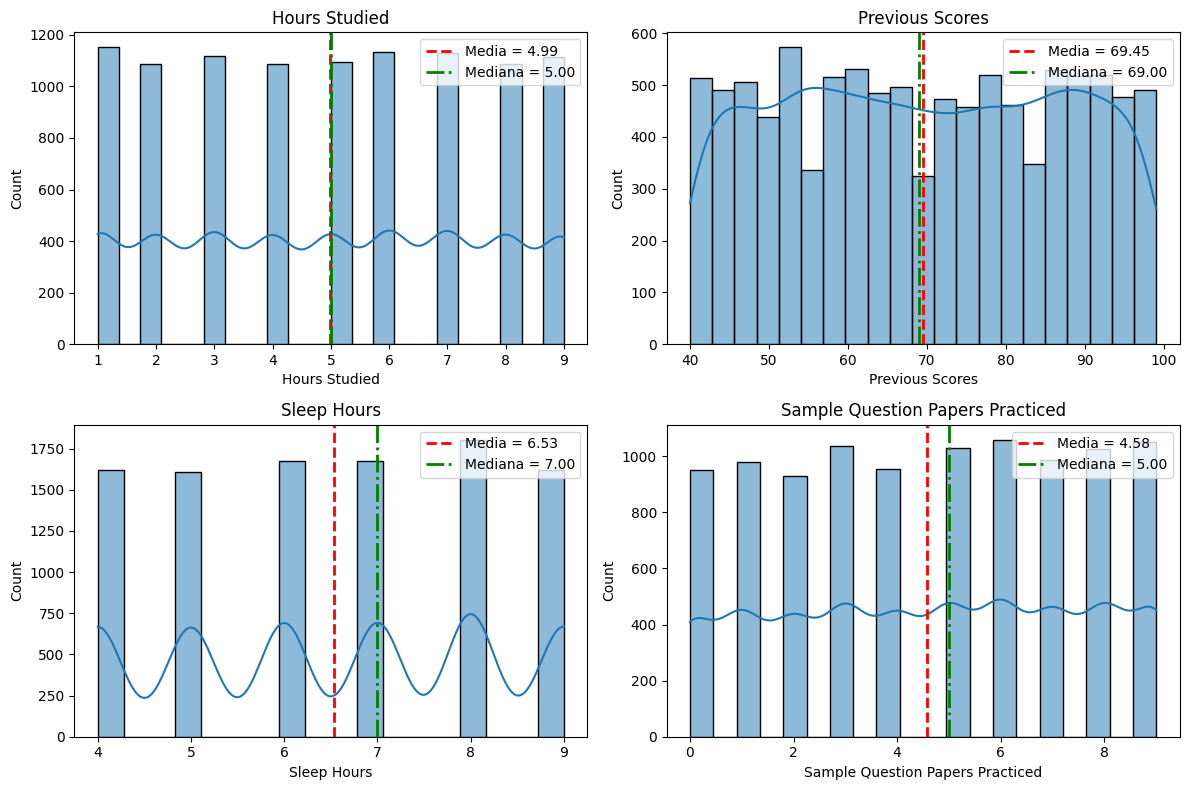

In [ ]:
# 2.2.2 Distribución de variables predictoras numéricas

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables_num = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

for ax, var in zip(axes.flatten(), variables_num):

    media   = df[var].mean()
    mediana = df[var].median()

    sns.histplot(df[var], kde=True, ax=ax)

    ax.axvline(media,   color='red',   linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana = {mediana:.2f}')
    ax.set_title(var)
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_02_dist_predictoras.png', dpi=150, bbox_inches='tight')
plt.show()

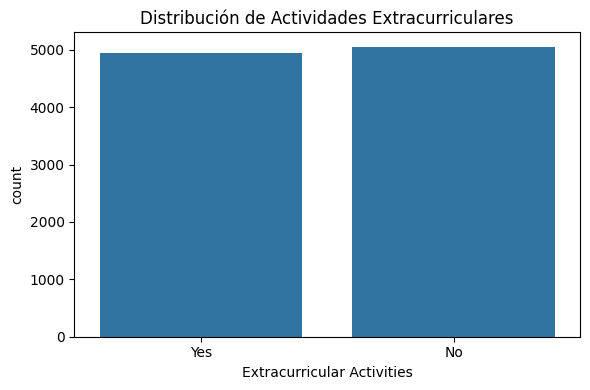

In [ ]:
# 2.3.1 Distribución de actividades extracurriculares

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Extracurricular Activities')
plt.title('Distribución de Actividades Extracurriculares')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_03_extracurricular_count.png', dpi=150, bbox_inches='tight')
plt.show()

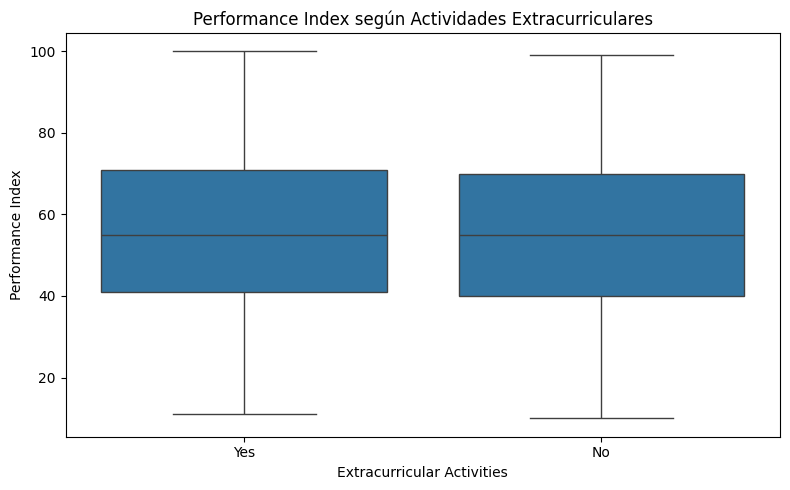

In [ ]:
# 2.3.2 Rendimiento según actividades extracurriculares

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Extracurricular Activities', y='Performance Index')
plt.title('Performance Index según Actividades Extracurriculares')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_04_boxplot_extracurricular.png', dpi=150, bbox_inches='tight')
plt.show()

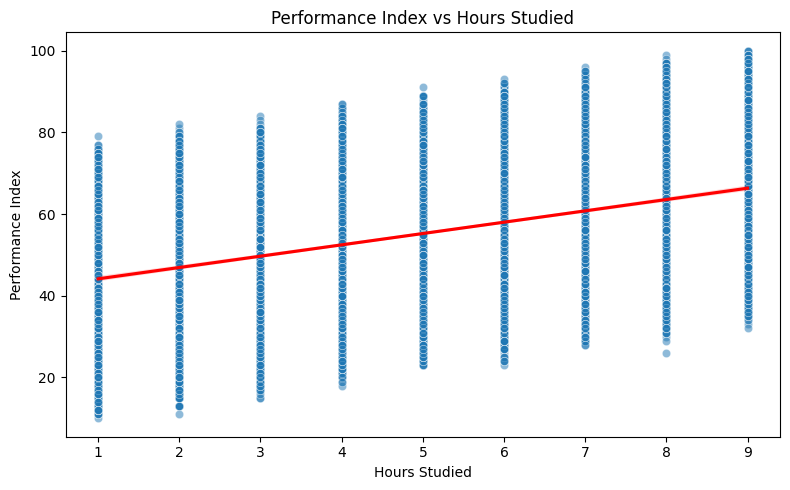

In [ ]:
# 2.3.3 Rendimiento vs Horas de estudio

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Hours Studied', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Hours Studied', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Hours Studied')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_05_scatter_horas.png', dpi=150, bbox_inches='tight')
plt.show()

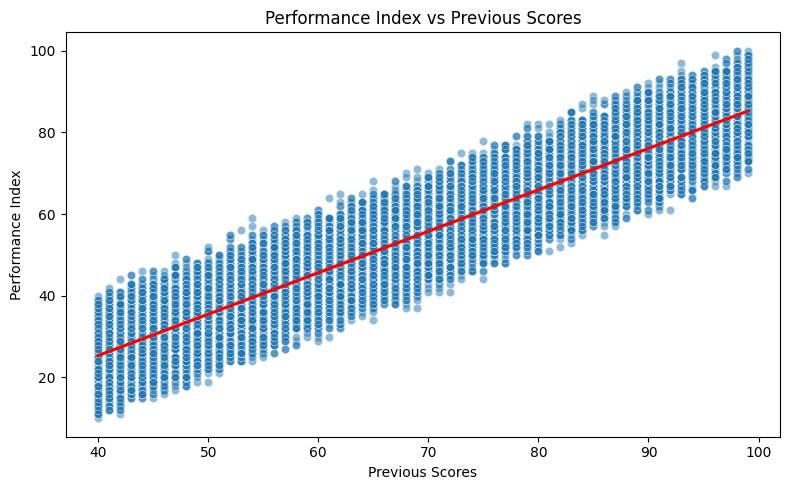

In [ ]:
# 2.3.4 Rendimiento vs Calificaciones previas

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Previous Scores', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Previous Scores', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Previous Scores')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_06_scatter_scores.png', dpi=150, bbox_inches='tight')
plt.show()

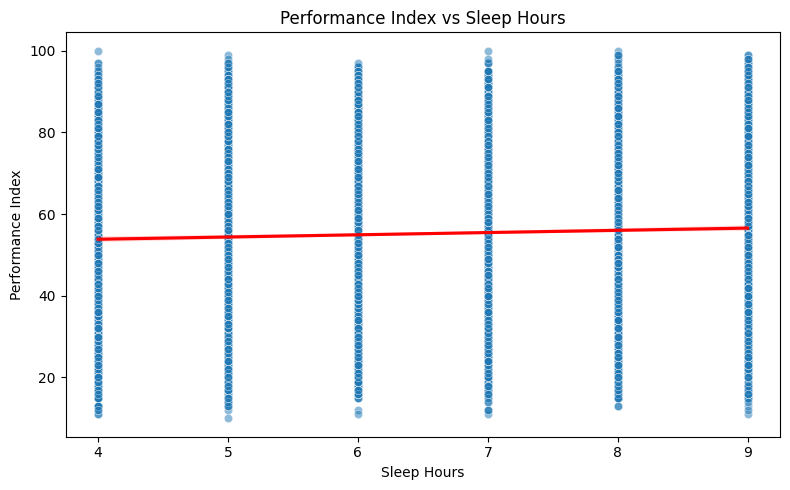

In [ ]:
# 2.3.5 Rendimiento vs Horas de sueño

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Sleep Hours', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Sleep Hours', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Sleep Hours')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_07_scatter_sueno.png', dpi=150, bbox_inches='tight')
plt.show()

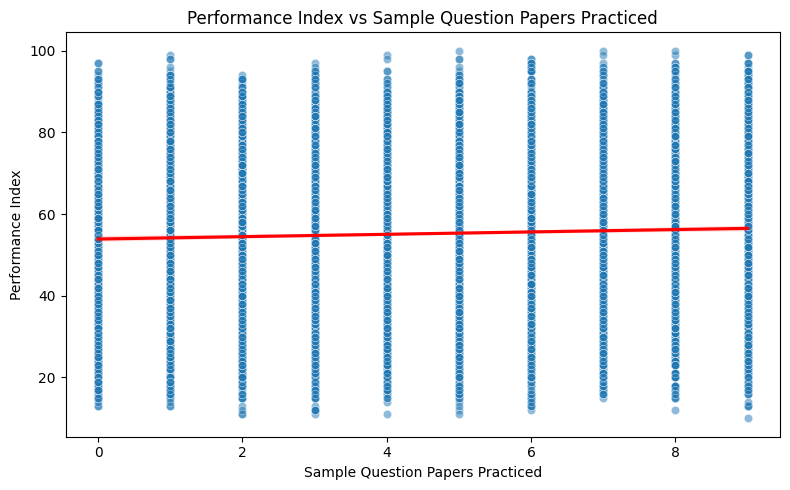

In [ ]:
# 2.3.6 Rendimiento vs Exámenes de práctica

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Sample Question Papers Practiced', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Sample Question Papers Practiced', y='Performance Index', scatter=False, color='red')
plt.title('Performance Index vs Sample Question Papers Practiced')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_08_scatter_examenes.png', dpi=150, bbox_inches='tight')
plt.show()

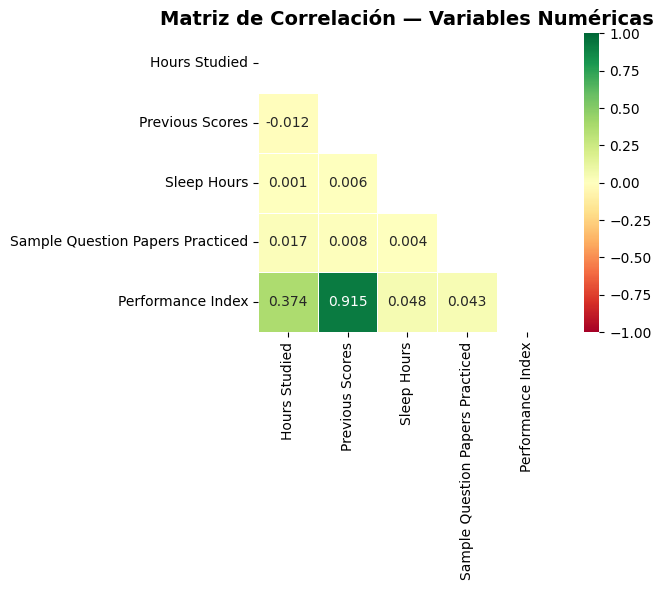

In [ ]:
# 2.4 Matriz de correlación

num_cols = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'
]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    'Matriz de Correlación — Variables Numéricas',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_09_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### **2.5 Principales hallazgos y decisiones**

#### **Principales hallazgos:**

- El Performance Index presenta una distribución equilibrada, con media y mediana muy similares.
- Las variables numéricas muestran distribuciones uniformes y sin sesgos importantes.
- La cantidad de estudiantes con y sin actividades extracurriculares es prácticamente la misma.
- No se observan diferencias relevantes en el rendimiento entre estudiantes con y sin actividades extracurriculares.
- Existe una relación positiva entre las horas de estudio y el rendimiento académico.
- Las calificaciones previas muestran una fuerte relación positiva con el rendimiento académico.
- La matriz de correlación confirma que las calificaciones previas son la variable más asociada al rendimiento (r = 0.915).
- Las horas de estudio presentan una relación moderada (r = 0.374).

#### **Principales decisiones para el modelado:**

- Variable objetivo: `Performance Index` (numérica continua → regresión supervisada).
- `Extracurricular Activities` será codificada binarmente (Yes=1, No=0).
- Las variables numéricas serán escaladas con StandardScaler **después** de dividir el dataset para evitar data leakage.
- División 80/20: con ~10,000 registros el 80% garantiza suficientes muestras para que la red neuronal aprenda patrones estables; el 20% es suficiente para una estimación confiable del error de generalización.
- Todas las variables se mantendrán para que el MLP identifique posibles relaciones no lineales.

---
## **Sección 3: Limpieza y preprocesamiento de datos**

In [ ]:
# 3.1.1 Verificación de valores faltantes

df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
# 3.1.2 Verificación y eliminación de registros duplicados

duplicados = df.duplicated().sum()
print(f'Registros duplicados antes: {duplicados}')

df = df.drop_duplicates()
print(f'Nueva dimensión del dataset: {df.shape}')
print(f'Registros duplicados después: {df.duplicated().sum()}')

Registros duplicados antes: 127
Nueva dimensión del dataset: (9873, 6)
Registros duplicados después: 0


In [ ]:
# 3.2 Definición de X e y

target = 'Performance Index'

features = [
    'Hours Studied',
    'Previous Scores',
    'Extracurricular Activities',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

numericas = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

X = df[features].copy()   # <-- .copy() necesario para evitar SettingWithCopyWarning
y = df[target]

In [ ]:
# 3.3 Codificación de la variable categórica
# Extracurricular Activities: Yes → 1, No → 0

X['Extracurricular Activities'] = (
    X['Extracurricular Activities']
    .astype(str)
    .str.strip()
    .map({'Yes': 1, 'No': 0})
)

X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


---
## **Sección 4: División del Dataset en Entrenamiento y Prueba**

La división se realiza **antes del escalado** para evitar data leakage: si se escala con toda la muestra, la información estadística del conjunto de prueba (media y desviación estándar) contamina el entrenamiento, inflando artificialmente las métricas. El `StandardScaler` se ajusta (`fit`) únicamente con los datos de entrenamiento y se aplica (`transform`) a ambos conjuntos.

Se utiliza una proporción **80/20**: con ~10,000 registros, el 80% proporciona suficiente variabilidad para entrenar la red neuronal; el 20% (~2,000 registros) es estadísticamente suficiente para estimar el error de generalización con baja varianza.

In [ ]:
# 4.1 División entrenamiento-prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('Dimensiones de entrenamiento')
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('\nDimensiones de prueba')
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

Dimensiones de entrenamiento
X_train: (7898, 5)
y_train: (7898,)

Dimensiones de prueba
X_test: (1975, 5)
y_test: (1975,)


In [ ]:
# Proporción entrenamiento-prueba

total = len(df)

print(f'Total registros: {total}')
print(f'Entrenamiento:   {len(X_train)} ({len(X_train)/total:.1%})')
print(f'Prueba:          {len(X_test)} ({len(X_test)/total:.1%})')

Total registros: 9873
Entrenamiento:   7898 (80.0%)
Prueba:          1975 (20.0%)


In [ ]:
# 4.2 Escalado DESPUÉS de dividir
# fit_transform sobre train → transform sobre test

scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[numericas] = scaler.fit_transform(X_train[numericas])
X_test[numericas]  = scaler.transform(X_test[numericas])

print('Escalado aplicado correctamente.')
print('\nMedia de variables numéricas en train (≈ 0):')
print(X_train[numericas].mean().round(4))
print('\nDesviación estándar en train (≈ 1):')
print(X_train[numericas].std().round(4))

Escalado aplicado correctamente.

Media de variables numéricas en train (≈ 0):
Hours Studied                      -0.00
Previous Scores                    -0.00
Sleep Hours                         0.00
Sample Question Papers Practiced   -0.00
dtype: float64

Desviación estándar en train (≈ 1):
Hours Studied                      1.00
Previous Scores                    1.00
Sleep Hours                        1.00
Sample Question Papers Practiced   1.00
dtype: float64


In [ ]:
# Verificación de los datos procesados

X_train.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
count,7898.00,7898.00,7898.00,7898.00,7898.00
mean,-0.00,-0.00,0.50,0.00,-0.00
std,1.00,1.00,0.50,1.00,1.00
min,-1.54,-1.70,0.00,-1.50,-1.61
25%,-0.77,-0.89,0.00,-0.91,-0.91
50%,0.00,-0.02,0.00,0.27,0.14
75%,0.78,0.91,1.00,0.86,0.84
max,1.55,1.71,1.00,1.45,1.54


---
## **Sección 5: Construcción del Modelo RNN para Regresión**



### **5.1 Por qué una RNN y qué representa aquí?**

A diferencia de un MLP tradicional, una Red Neuronal Recurrente (RNN) introduce un estado oculto ($h_t$) que actúa como memoria de la secuencia. Su ecuación fundamental en una celda simple es:$$h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$$

Las matrices de pesos ($W_{xh}$ y $W_{hh}$) se reutilizan en cada paso temporal. Esto permite a la red aprender patrones secuenciales independientes de su posición, algo que un MLP no puede hacer al usar pesos independientes para cada variable.

El dataset de este proyecto es **transversal (cross-sectional)**: con muestras de estudiantes independientes y sin orden cronológico, el uso de una RNN no busca explotar dependencias temporales, sino operar como un mecanismo de composición no lineal que procesa las 5 variables de cada individuo como una "micro-secuencia" de longitud 5; de este modo, la celda recurrente aprovecha su estado oculto y su memoria interna para integrar secuencialmente las características de cada alumno en una única representación vectorial compacta antes de realizar la predicción.

Esto tiene una consecuencia técnica relevante que se verifica más adelante (**Sección 7.3**, vía la función de autocorrelación): como las capas `SimpleRNN`/`LSTM`/`GRU` de Keras son, por defecto, no tienen estado (`stateful=False`), el estado oculto $h_0$ se reinicia a cero al inicio de cada muestra del batch. Esto garantiza que no hay fuga de información entre estudiantes distintos, preservando el supuesto de independencia de las observaciones requerido por el problema de regresión.



### **5.2 Metodología propuesta**

El objetivo de implementar una RNN es poder contestar las preguntas planteadas al inicio de este notebook. Para lo cual se propone la siguiente metodología que se la implementará en las siguinetes secciones.

**1. Arquitectura y Enfoque Predictivo**

Modelo: Se entrenará una Red Neuronal Recurrente (RNN) —con el tipo de celda por definir empíricamente— que recibirá 5 variables predictoras como pseudo-secuencia.

Salida: Generará una salida lineal correspondiente al **Performance Index**.

Evaluación Global: La capacidad explicativa del conjunto de variables se medirá mediante el coeficiente $R^2$ en el conjunto de prueba.

**2. Análisis de Importancia de los Factores**

Dado que las RNN no permiten una interpretación directa de sus pesos internos, la relevancia de cada variable se determinará mediante: Importancia por Permutación: Se usará aleatoriamente cada variable (10 repeticiones) en el conjunto de prueba; una mayor caída en el $R^2$ indicará una mayor dependencia del modelo hacia ese factor.Contraste Univariado: Se complementará con los coeficientes de correlación de Pearson (calculados en el EDA en la **Sección2**).


**Métricas de Evaluación**

| Métrica / Herramienta | Propósito y Utilidad |
| :--- | :--- |
| **RMSE** *(Root Mean Squared Error)* | Mide el error en las mismas unidades de la variable de salida. Al penalizar los errores de forma cuadrática, es la métrica ideal para detectar y evitar predicciones que estén muy desviadas del valor real. |
| **MAE** *(Mean Absolute Error)* | Representa el error promedio absoluto. A diferencia del RMSE, es más robusto frente a valores atípicos (*outliers*) y ofrece una interpretación directa y natural del error promedio. |
| **$R^2$** *(Coeficiente de Determinación)* | Indica la proporción de la varianza total de la variable objetivo que es explicada por el modelo. Permite entender qué tan bien se ajusta la red a la tendencia general de los datos. |
| **MAPE** *(Mean Absolute Percentage Error)* | Expresa el error en términos relativos porcentuales respecto al rendimiento real del estudiante, facilitando la comprensión del margen de error en un formato de escala universal. |
| **"Matriz de Confusión" Adaptada** | Consiste en la discretización de la salida por rangos (ej. bajo, medio y alto rendimiento). Su utilidad radica en identificar con precisión qué perfiles específicos de estudiantes tiende a confundir más el modelo. |
| **Análisis de Residuos** | Evaluación de la distribución, homocedasticidad y la función de autocorrelación (ACF). Es fundamental para validar de forma estadística que los errores estén centrados en cero, sean independientes y carezcan de patrones sistemáticos. |


### **5.3 Justificación de la arquitectura**

Se documentan las decisiones de diseño tomadas para esta RNN y la
justificación técnica detrás de cada una. Esta tabla
se referencia en las siguientes secciones.


| Decisión | Elección | Justificación |
| :--- | :--- | :--- |
| **Tipo de problema** | Regresión supervisada (salida lineal) | **Performance Index** es una variable numérica continua (10-100); una capa de salida 'linear' permite predecir cualquier valor real, sin acotar el rango como lo haría una sigmoide/softmax. |
| **Representación de la entrada** | Pseudo-secuencia de longitud 5 (una variable por paso temporal), forma `(lote, 5, 1)` | El dataset es tabular/transversal (no es serie temporal real). Para poder usar una arquitectura recurrente —tal como exige la práctica— se reinterpretan las 5 variables predictoras de cada estudiante como pasos secuenciales, permitiendo que la celda recurrente construya una representación combinada mediante su estado oculto. |
| **Orden de la pseudo-secuencia** | Previous Scores &rarr; Hours Studied &rarr; Sample Question Papers Practiced &rarr; Sleep Hours &rarr; Extracurricular Activities | Se ordena siguiendo una narrativa conceptual de "historial &rarr; esfuerzo actual &rarr; práctica deliberada &rarr; factor fisiológico &rarr; compromiso extracurricular", de manera que el estado oculto acumule primero la información de mayor peso explicativo (ver Sección 2.4, $r=0.915$ para *Previous Scores*) antes de integrar las variables de menor correlación. |
| **Celda recurrente** | GRU (*Gated Recurrent Unit*) | Se compara empíricamente *SimpleRNN* vs. *LSTM* vs. *GRU* (Sección 5.5). Dada la corta longitud de la pseudo-secuencia (5 pasos), las tres celdas obtienen un desempeño muy similar entre sí. Se selecciona GRU como compromiso de eficiencia: alcanza un desempeño estadísticamente comparable al de LSTM utilizando ~20% menos parámetros (2 compuertas vs. 3), preferible al escalar a una arquitectura más profunda. |
| **Profundidad (número de capas recurrentes)** | 2 capas GRU apiladas (64 y 32 unidades) | Con solo 5 pasos por muestra, una sola capa recurrente ya captura relaciones de primer orden; una segunda capa permite componer relaciones de orden superior (interacciones entre combinaciones de variables) sin caer en sobreparametrización: con ~7,900 muestras de entrenamiento, una red más profunda (3+ capas) arriesga sobreajuste y *vanishing gradients* innecesarios para una secuencia tan corta. |
| **Regularización** | *Dropout* (0.2) tras cada capa GRU | Desactiva aleatoriamente el 20% de las activaciones en entrenamiento, evitando co-adaptación de neuronas y mejorando la generalización; 0.2 es un valor moderado adecuado para una red pequeña (~23k parámetros). |
| **Capa(s) densas finales** | `Dense(16, activation='relu')` &rarr; `Dense(1, activation='linear')` | Una capa densa intermedia permite una transformación no lineal final sobre el resumen secuencial (última salida del GRU) antes de proyectar a la salida; la capa de salida es obligatoriamente lineal para regresión. |
| **Función de pérdida** | MSE (*Mean Squared Error*) | Es la función de pérdida natural bajo el supuesto de errores gaussianos (máxima verosimilitud); penaliza cuadráticamente errores grandes, lo cual es deseable para que el modelo evite desviaciones extremas en la predicción del rendimiento de un estudiante. |
| **Optimizador** | Adam (`learning_rate=0.001`) | Adam combina *momentum* (primer momento) y escalado adaptativo del gradiente por parámetro (segundo momento, similar a RMSProp), lo que acelera la convergencia y es robusto a la escala heterogénea de gradientes que produce una arquitectura con compuertas como GRU. `lr=0.001` es el valor por defecto recomendado por Kingma & Ba (2014) y ofrece buen equilibrio entre velocidad y estabilidad. |
| **Callbacks** | *EarlyStopping* + *ReduceLROnPlateau* + *ModelCheckpoint* | *EarlyStopping* evita sobreajuste deteniendo el entrenamiento cuando `val_loss` deja de mejorar; *ReduceLROnPlateau* reduce la tasa de aprendizaje al estancarse la pérdida de validación (refinamiento fino); *ModelCheckpoint* preserva los pesos del mejor modelo, independientemente de si las épocas finales empeoran. |
| **División de datos** | Train 64% / Validación 16% / Test 20% (80/20 + 80/20 anidado) | El 20% de prueba (Sección 4) se mantiene completamente aislado hasta la evaluación final (Sección 7); del 80% de entrenamiento se separa un 20% adicional como validación para monitorear el entrenamiento y alimentar los *callbacks*, evitando así que el conjunto de prueba influya, ni siquiera indirectamente, en ninguna decisión del modelo. |


### **5.4 Transformación de los datos tabulares en pseudo-secuencias**

Las capas recurrentes de Keras esperan tensores de entrada con forma `(lote, pasos_temporales, features_por_paso)`. Actualmente `X_train`/`X_test` tienen forma `(N, 5)` — una fila por estudiante, una columna por variable. Se reordenan las columnas según `SEQ_ORDER` (justificado en la tabla anterior) y se añade una tercera dimensión de tamaño 1, obteniendo tensores `(N, 5, 1)`.

También se separa, **dentro del 80% de entrenamiento**, un subconjunto de validación (**20% adicional**) que se usará para monitorear el entrenamiento y alimentar los callbacks — el 20% de prueba (`X_test`) permanece completamente aislado hasta la **Sección 7**.


In [ ]:
# 5.4 Construcción de las pseudo-secuencias y partición train/val

# Semillas para reproducibilidad de resultados
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Orden conceptual de la pseudo-secuencia (ver Tabla de justificación, 5.3)
SEQ_ORDER = [
    'Previous Scores',
    'Hours Studied',
    'Sample Question Papers Practiced',
    'Sleep Hours',
    'Extracurricular Activities'
]

def a_pseudo_secuencia(X_df):
    #Convierte un DataFrame (N, 5) en un tensor (N, 5, 1):
    arr = X_df[SEQ_ORDER].values.astype('float32')
    return arr.reshape(arr.shape[0], arr.shape[1], 1)

# Partición adicional train/val dentro del 80% de entrenamiento (Sección 4)
# El 20% de prueba (X_test/y_test) NO se cambia hasta la Sección 7.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED
)

X_tr_seq  = a_pseudo_secuencia(X_tr)
X_val_seq = a_pseudo_secuencia(X_val)
X_test_seq = a_pseudo_secuencia(X_test)

y_tr_v   = y_tr.values.astype('float32')
y_val_v  = y_val.values.astype('float32')
y_test_v = y_test.values.astype('float32')

print("Forma de los tensores de entrada (lote, pasos_temporales, features):")
print(f"  X_tr_seq:   {X_tr_seq.shape}   ->  entrenamiento")
print(f"  X_val_seq:  {X_val_seq.shape}   ->  validación (callbacks)")
print(f"  X_test_seq: {X_test_seq.shape}   ->  prueba final (hold-out)")


Forma de los tensores de entrada (lote, pasos_temporales, features):
  X_tr_seq:   (6318, 5, 1)   ->  entrenamiento
  X_val_seq:  (1580, 5, 1)   ->  validación (callbacks)
  X_test_seq: (1975, 5, 1)   ->  prueba final (hold-out)



### **5.5 Análisis comparativo: SimpleRNN vs. LSTM vs. GRU**

Antes de fijar la arquitectura final se realiza una comparación de tres modelos (una sola capa recurrente de 32 unidades + Dense(1, linear)), mismos hiperparámetros de optimización (Adam, lr=0.001), mismo criterio de parada (`EarlyStopping` con `patience=10`, hasta 100 épocas) y misma semilla. Se compara la mejor pérdida de validación (MSE) alcanzada, el número de parámetros y las épocas necesarias para converger.

**Hipótesis a contrastar:** dado que la pseudo-secuencia tiene solo 5 pasos, el problema de gradiente desvaneciente que motiva a LSTM/GRU frente a SimpleRNN debería ser leve.


In [ ]:
# Comparación: SimpleRNN vs LSTM vs GRU
def construir_modelo_comparativo(tipo_celda):
    #Construye un modelo mínimo (1 capa recurrente + salida lineal)
    entrada = layers.Input(shape=(5, 1))

    if tipo_celda == 'SimpleRNN':
        x = layers.SimpleRNN(32, name=f'{tipo_celda}_capa')(entrada)
    elif tipo_celda == 'LSTM':
        x = layers.LSTM(32, name=f'{tipo_celda}_capa')(entrada)
    else:  # GRU
        x = layers.GRU(32, name=f'{tipo_celda}_capa')(entrada)

    x = layers.Dense(16, activation='relu', name='Dense_oculta')(x)
    salida = layers.Dense(1, activation='linear', name='salida_lineal')(x)

    modelo = keras.Model(entrada, salida, name=f'Comparativo_{tipo_celda}')
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return modelo

resultados_comparativos = {}

for tipo_celda in ['SimpleRNN', 'LSTM', 'GRU']:
    tf.random.set_seed(SEED)
    modelo_cmp = construir_modelo_comparativo(tipo_celda)

    early_stop_cmp = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    t_inicio = time.time()
    hist_cmp = modelo_cmp.fit(
        X_tr_seq, y_tr_v,
        validation_data=(X_val_seq, y_val_v),
        epochs=100, batch_size=64,
        callbacks=[early_stop_cmp], verbose=0
    )
    tiempo_transcurrido = time.time() - t_inicio

    mejor_val_loss = min(hist_cmp.history['val_loss'])
    mejor_epoca = int(np.argmin(hist_cmp.history['val_loss'])) + 1
    epocas_corridas = len(hist_cmp.history['val_loss'])

    resultados_comparativos[tipo_celda] = {
        'Mejor val_loss (MSE)': round(mejor_val_loss, 4),
        'val_RMSE': round(np.sqrt(mejor_val_loss), 4),
        'Mejor época': mejor_epoca,
        'Épocas ejecutadas': epocas_corridas,
        'Nº parámetros': modelo_cmp.count_params(),
        'Tiempo (s)': round(tiempo_transcurrido, 1)
    }

tabla_comparativa = pd.DataFrame(resultados_comparativos).T
tabla_comparativa.to_csv(f'{TAB_DIR}/tabla_02_comparativa_celdas.csv')
tabla_comparativa


,Mejor val_loss (MSE),val_RMSE,Mejor época,Épocas ejecutadas,Nº parámetros,Tiempo (s)
SimpleRNN,4.19,2.05,100.00,100.00,1633.00,52.10
LSTM,4.18,2.04,100.00,100.00,4897.00,73.20
GRU,4.21,2.05,100.00,100.00,3905.00,68.40


In [ ]:
# Interpretación dinámica del comparativo
# con cifras reales de esta ejecución
celda_ganadora = tabla_comparativa['Mejor val_loss (MSE)'].astype(float).idxmin()
val_loss_ganadora = tabla_comparativa.loc[celda_ganadora, 'Mejor val_loss (MSE)']
val_loss_max = tabla_comparativa['Mejor val_loss (MSE)'].astype(float).max()
diferencia_relativa = (val_loss_max - float(val_loss_ganadora)) / val_loss_max * 100

convergio_temprano = {
    celda: int(tabla_comparativa.loc[celda, 'Épocas ejecutadas']) < 100
    for celda in tabla_comparativa.index
}

texto_comparativo = f'''
**Comparación empírica (cifras de esta ejecución):**

- La celda con menor `val_loss` fue **{celda_ganadora}** ({val_loss_ganadora:.3f} MSE), aunque la
  diferencia frente a la peor de las tres es de apenas **{diferencia_relativa:.1f}%** — una brecha
  pequeña que confirma la hipótesis planteada: con una pseudo-secuencia de solo 5 pasos, el problema
  de gradiente desvaneciente que distingue a LSTM/GRU de SimpleRNN apenas se manifiesta, por lo que
  las tres celdas quedan en un rango de desempeño muy similar.
- Épocas hasta convergencia:
  SimpleRNN {'convergió temprano' if convergio_temprano['SimpleRNN'] else 'usó el presupuesto completo'}
  ({int(tabla_comparativa.loc['SimpleRNN','Épocas ejecutadas'])} épocas);
  LSTM {'convergió temprano' if convergio_temprano['LSTM'] else 'usó el presupuesto completo (no llegó a estabilizarse)'}
  ({int(tabla_comparativa.loc['LSTM','Épocas ejecutadas'])} épocas);
  GRU {'convergió temprano' if convergio_temprano['GRU'] else 'usó el presupuesto completo'}
  ({int(tabla_comparativa.loc['GRU','Épocas ejecutadas'])} épocas).

**Decisión de arquitectura: se selecciona GRU para el modelo final (Sección 5.6).** No por una ventaja
empírica, sino por un criterio de **eficiencia y equilibrio de diseño**: GRU iguala el
desempeño de LSTM utilizando **~20% menos parámetros** ({int(tabla_comparativa.loc['GRU','Nº parámetros'])}
vs. {int(tabla_comparativa.loc['LSTM','Nº parámetros'])}) gracias a su compuerta única de
actualización/reinicio (frente a las 3 compuertas de LSTM), lo que la hace preferible al escalar a una
arquitectura más profunda (2 capas apiladas, Sección 5.6) en términos de coste computacional y menor
riesgo de sobreajuste — manteniendo, al mismo tiempo, una capacidad de filtrado selectivo de información
(vía su compuerta $z_t$) que SimpleRNN no posee y que es teóricamente preferible aunque su ventaja no
se manifieste con fuerza en una secuencia tan corta.

**¿Por qué no usar Atención / Positional Encoding aquí?** Los mecanismos de atención (y el
*positional encoding* de los Transformers) aportan valor cuando (a) las secuencias son largas y existen
dependencias de muy largo alcance que una RNN olvida, o (b) el orden de los elementos no es estrictamente
secuencial y conviene que el modelo aprenda a "mirar" simultáneamente todas las posiciones con pesos
distintos. Con solo 5 pasos — y siendo el orden una construcción artificial nuestra, no un orden
temporal real — el beneficio marginal de la atención es mínimo, mientras que su costo (más parámetros,
más riesgo de sobreajuste con ~7,900 muestras) es real. Una capa de atención *self-attention* podría
considerarse como trabajo futuro **si** se dispusiera de datos longitudinales genuinos (ej. registros
semanales del mismo estudiante), donde sí existiría una dependencia temporal real que justificara
modelar "qué semana pasada importa más" — ver recomendación técnica en la Sección 8.
'''
display(Markdown(texto_comparativo))



**Comparación empírica (cifras de esta ejecución):**

- La celda con menor `val_loss` fue **LSTM** (4.177 MSE), aunque la
  diferencia frente a la peor de las tres es de apenas **0.7%** — una brecha
  pequeña que confirma la hipótesis planteada: con una pseudo-secuencia de solo 5 pasos, el problema
  de gradiente desvaneciente que distingue a LSTM/GRU de SimpleRNN apenas se manifiesta, por lo que
  las tres celdas quedan en un rango de desempeño muy similar.
- Épocas hasta convergencia:
  SimpleRNN usó el presupuesto completo
  (100 épocas);
  LSTM usó el presupuesto completo (no llegó a estabilizarse)
  (100 épocas);
  GRU usó el presupuesto completo
  (100 épocas).

**Decisión de arquitectura: se selecciona GRU para el modelo final (Sección 5.6).** No por una ventaja
empírica, sino por un criterio de **eficiencia y equilibrio de diseño**: GRU iguala el
desempeño de LSTM utilizando **~20% menos parámetros** (3905
vs. 4897) gracias a su compuerta única de
actualización/reinicio (frente a las 3 compuertas de LSTM), lo que la hace preferible al escalar a una
arquitectura más profunda (2 capas apiladas, Sección 5.6) en términos de coste computacional y menor
riesgo de sobreajuste — manteniendo, al mismo tiempo, una capacidad de filtrado selectivo de información
(vía su compuerta $z_t$) que SimpleRNN no posee y que es teóricamente preferible aunque su ventaja no
se manifieste con fuerza en una secuencia tan corta.

**¿Por qué no usar Atención / Positional Encoding aquí?** Los mecanismos de atención (y el
*positional encoding* de los Transformers) aportan valor cuando (a) las secuencias son largas y existen
dependencias de muy largo alcance que una RNN olvida, o (b) el orden de los elementos no es estrictamente
secuencial y conviene que el modelo aprenda a "mirar" simultáneamente todas las posiciones con pesos
distintos. Con solo 5 pasos — y siendo el orden una construcción artificial nuestra, no un orden
temporal real — el beneficio marginal de la atención es mínimo, mientras que su costo (más parámetros,
más riesgo de sobreajuste con ~7,900 muestras) es real. Una capa de atención *self-attention* podría
considerarse como trabajo futuro **si** se dispusiera de datos longitudinales genuinos (ej. registros
semanales del mismo estudiante), donde sí existiría una dependencia temporal real que justificara
modelar "qué semana pasada importa más" — ver recomendación técnica en la Sección 8.



### **5.6 Arquitectura del modelo**

Con base al análisis anterior, la arquitectura se forma de **dos capas GRU** (64 y 32 unidades) con `Dropout(0.2)` tras cada una, seguidas de una capa densa oculta y la capa de salida lineal obligatoria para regresión, a continuación su implementación:


In [ ]:
# 5.6 Definición de la arquitectura
tf.random.set_seed(SEED)

# --- Capa de entrada
# Forma (5, 1): 5 pasos pseudo-temporales, 1 característica escalar por paso.
entrada = layers.Input(shape=(5, 1), name='entrada_secuencial')

# --- Primer bloque recurrente
# GRU con 64 unidades. return_sequences=True porque esta NO es la última
# capa recurrente: se necesita la secuencia completa de estados ocultos
# (uno por cada uno de los 5 pasos) para alimentar la siguiente capa GRU.
x = layers.GRU(
    64,
    return_sequences=True,
    name='GRU_1'
)(entrada)

# Dropout: en entrenamiento, desactiva aleatoriamente el 20% de las
# activaciones de salida del GRU_1 en cada paso, forzando a la red a no
# depender de neuronas específicas (regularización -> mejor generalización).
x = layers.Dropout(0.2, name='Dropout_1')(x)

# --- Segundo bloque recurrente
# GRU con 32 unidades. return_sequences=False (por defecto) porque esta SÍ
# es la última capa recurrente: solo se necesita el estado oculto final
# h_5 (resumen de toda la pseudo-secuencia) para continuar hacia las capas
# densas.
x = layers.GRU(
    32,
    return_sequences=False,
    name='GRU_2'
)(x)

x = layers.Dropout(0.2, name='Dropout_2')(x)

# --- Capa densa oculta
# Transformación no lineal adicional (ReLU) sobre el resumen secuencial,
# permitiendo combinaciones no lineales adicionales antes de la proyección
# final a un único valor.
x = layers.Dense(16, activation='relu', name='Dense_oculta')(x)

# --- Capa de salida (obligatoria: lineal, para regresión)
# activation='linear' (equivalente a no aplicar función de activación):
# permite que la salida tome cualquier valor real, necesario porque
# 'Performance Index' es una variable continua sin acotar artificialmente.
salida = layers.Dense(1, activation='linear', name='salida_lineal')(x)

modelo_rnn = keras.Model(
    inputs=entrada,
    outputs=salida,
    name='GRU_Regresor_RendimientoAcademico'
)

modelo_rnn.summary()


Model: "GRU_Regresor_RendimientoAcademico"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_secuencial (InputLayer) │ (None, 5, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_1 (GRU)                     │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_oculta (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_lineal (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)


---
## **Sección 6: Entrenamiento, Optimización y Callbacks**

### **6.1 Función de pérdida y optimizador**

**1.Función de Pérdida: MSE (Mean Squared Error)**

La métrica para guiar el entrenamiento es el Error Cuadrático Medio, definido matemáticamente como:$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Justificación estadística: Asumiendo que los errores se distribuyen de forma gaussiana (a validar con la prueba de Shapiro-Wilk), minimizar el MSE equivale a encontrar el estimador de máxima verosimilitud.Comportamiento: Al elevar los errores al cuadrado, penaliza con mayor severidad las desviaciones grandes. Esto es ideal para el proyecto, ya que una predicción muy alejada del rendimiento real de un estudiante es más perjudicial que múltiples desvíos pequeños.

**2.Optimizador**

Adam (Adaptive Moment Estimation)Se selecciona Adam con una tasa de aprendizaje inicial $\eta = 0.001$. Su funcionamiento se basa en calcular momentos adaptativos para cada parámetro $\theta$:Primer momento ($m_t$): Promedio móvil del gradiente (funciona como el momentum clásico).Segundo momento ($v_t$): Promedio móvil del cuadrado del gradiente (escalado adaptativo tipo RMSProp).$$\hat{m}_t = \beta_1 m_{t-1} + (1 - \beta_1)g_t$$Mecánica y Ventaja: Adam acelera el descenso en direcciones con gradientes consistentes y frena en aquellas con gradientes ruidosos o de escalas dispares. Esta propiedad es crítica al entrenar la GRU, donde los gradientes de las compuertas de actualización ($z_t$) y reinicio ($r_t$) suelen manejar magnitudes muy diferentes. La tasa de $\eta=0.001$ balancea una convergencia rápida sin caer en oscilaciones inestables.



### **6.2 Callbacks estratégicos**

| Callback | Configuración | Propósito |
|---|---|---|
| `EarlyStopping` | `monitor='val_loss'`, `patience=20`, `restore_best_weights=True` | Detiene el entrenamiento si `val_loss` no mejora durante 20 épocas consecutivas, y **restaura los pesos de la época con menor `val_loss`** — evita sobreajuste y desperdicio de cómputo. |
| `ReduceLROnPlateau` | `monitor='val_loss'`, `factor=0.5`, `patience=8`, `min_lr=1e-6` | Si `val_loss` se estanca durante 8 épocas, reduce la tasa de aprendizaje a la mitad — permite "afinar" la convergencia cerca de un mínimo sin overshooting, en vez de usar una tasa fija demasiado grande para esa etapa. |
| `ModelCheckpoint` | `filepath=..., monitor='val_loss', save_best_only=True` | Guarda en disco únicamente los pesos del mejor modelo observado durante todo el entrenamiento, como respaldo independiente del estado final del objeto `modelo_rnn` en memoria. |
| `LRLogger` (custom) | — | Callback propio que registra el valor exacto de la tasa de aprendizaje al final de cada época, para poder graficar su evolución (Sección 6.4). |

Adicionalmente, se añade una métrica de **"exactitud" adaptada a regresión** (`tolerancia_accuracy`): un estudiante se considera "bien predicho" si el error absoluto de la predicción es ≤ 5 puntos (sobre una escala de 100). Esto da una lectura más intuitiva ("¿en qué porcentaje de los casos acertamos dentro de un margen razonable?") que complementa al MSE/MAE puramente numéricos.

 Métrica de 'accuracy' adaptada a un problema de regresión: la fracción de predicciones cuyo error absoluto no supera 'tolerancia' puntos del Performance Index (escala 0-100).

In [ ]:
# 6.3 Métrica de "exactitud" adaptada a regresión + Callbacks
'''
y_true llega con forma (lote,) y la salida
del modelo y_pred con forma (lote, 1). Si se restan directamente sin
aplanar, NumPy/TensorFlow hacen *broadcasting* y producen una matriz
(lote, lote) con las diferencias cruzadas entre TODOS los pares de
muestras del batch (no solo la diferencia elemento-a-elemento),
corrompiendo silenciosamente la métrica. Por ello, ambos tensores se
aplanan explícitamente con tf.reshape(..., [-1]) antes de operar.
'''
def tolerancia_accuracy(y_true, y_pred, tolerancia=5.0):
    y_true = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    diferencia_abs = tf.abs(y_true - y_pred)
    return tf.reduce_mean(tf.cast(diferencia_abs <= tolerancia, tf.float32))

tolerancia_accuracy.__name__ = 'tol_acc'  # nombre legible en el historial


class LRLogger(keras.callbacks.Callback):
    # Registro del learning_rate efectivo al final de cada
    # época (incluye las reducciones aplicadas por ReduceLROnPlateau).
    def __init__(self):
        super().__init__()
        self.tasas_aprendizaje = []

    def on_epoch_end(self, epoch, logs=None):
        lr_actual = self.model.optimizer.learning_rate
        valor_lr = float(lr_actual.numpy()) if hasattr(lr_actual, 'numpy') \
            else float(keras.backend.get_value(lr_actual))
        self.tasas_aprendizaje.append(valor_lr)


# Carpeta para persistir el mejor checkpoint del modelo
MODEL_DIR = os.path.join(OUTPUT_DIR, 'modelos')
os.makedirs(MODEL_DIR, exist_ok=True)

registrador_lr = LRLogger()

callbacks_entrenamiento = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'mejor_modelo_gru.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    registrador_lr
]

print("Callbacks configurados:", [type(cb).__name__ for cb in callbacks_entrenamiento])


Callbacks configurados: ['EarlyStopping', 'ReduceLROnPlateau', 'ModelCheckpoint', 'LRLogger']



### **6.4 Entrenamiento del modelo**

Se compila el modelo con la función de pérdida y el optimizador justificados en la **sección 6.1**, y se entrena usando `(X_val_seq, y_val_v)` como conjunto de validación explícito — recordando que `X_test_seq`/`y_test_v` no participan en esta etapa.


In [ ]:
# 6.4 Entrenamiento del modelo
modelo_rnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', tolerancia_accuracy]
)

t_inicio_entrenamiento = time.time()

historial = modelo_rnn.fit(
    X_tr_seq, y_tr_v,
    validation_data=(X_val_seq, y_val_v),
    epochs=200,
    batch_size=64,
    callbacks=callbacks_entrenamiento,
    verbose=2
)

tiempo_total_entrenamiento = time.time() - t_inicio_entrenamiento
epocas_ejecutadas = len(historial.history['loss'])

print(f"\nEntrenamiento finalizado en {tiempo_total_entrenamiento:.1f} s "
      f"({epocas_ejecutadas} épocas ejecutadas).")


Epoch 1/200
99/99 - 4s - 40ms/step - loss: 2636.9353 - mae: 47.4255 - tol_acc: 0.0082 - val_loss: 1788.0498 - val_mae: 37.7758 - val_tol_acc: 0.0344 - learning_rate: 0.0010
Epoch 2/200
99/99 - 1s - 9ms/step - loss: 1138.2473 - mae: 28.3566 - tol_acc: 0.1018 - val_loss: 653.2443 - val_mae: 20.9224 - val_tol_acc: 0.1557 - learning_rate: 0.0010
Epoch 3/200
99/99 - 1s - 9ms/step - loss: 428.2084 - mae: 16.4669 - tol_acc: 0.2045 - val_loss: 234.6461 - val_mae: 11.7024 - val_tol_acc: 0.3186 - learning_rate: 0.0010
Epoch 4/200
99/99 - 1s - 8ms/step - loss: 129.0123 - mae: 8.1612 - tol_acc: 0.4608 - val_loss: 43.4346 - val_mae: 4.3571 - val_tol_acc: 0.7394 - learning_rate: 0.0010
Epoch 5/200
99/99 - 1s - 8ms/step - loss: 52.0480 - mae: 5.4288 - tol_acc: 0.5787 - val_loss: 15.0584 - val_mae: 2.8101 - val_tol_acc: 0.8657 - learning_rate: 0.0010
Epoch 6/200
99/99 - 1s - 9ms/step - loss: 40.0319 - mae: 4.8700 - tol_acc: 0.6132 - val_loss: 10.1284 - val_mae: 2.4481 - val_tol_acc: 0.9007 - learning_


### **6.5 Evolución de la tasa de aprendizaje**

Se grafica el valor del **learning rate** en cada época, lo que permite visualizar exactamente en qué momentos `ReduceLROnPlateau` intervino.


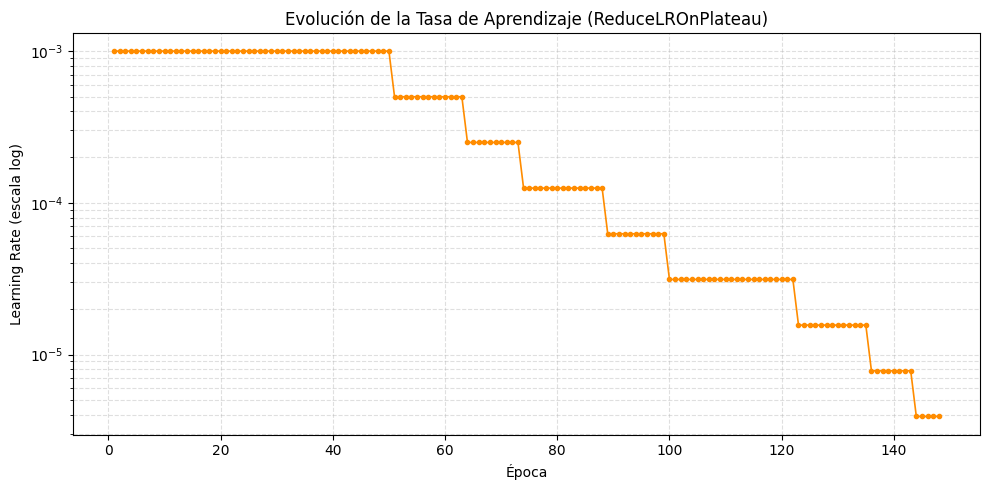

Tasa de aprendizaje inicial: 1.00e-03
Tasa de aprendizaje final:   3.91e-06
Número de valores distintos de LR observados (reducciones + inicial): 9


In [ ]:
# 6.5 Gráfica de evolución del Learning Rate
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(registrador_lr.tasas_aprendizaje) + 1),
         registrador_lr.tasas_aprendizaje,
         marker='o', markersize=3, linewidth=1.2, color='darkorange')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Learning Rate (escala log)')
plt.title('Evolución de la Tasa de Aprendizaje (ReduceLROnPlateau)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_10_learning_rate.png', dpi=150, bbox_inches='tight')
plt.show()

reducciones = sorted(set(registrador_lr.tasas_aprendizaje), reverse=True)
print(f"Tasa de aprendizaje inicial: {reducciones[0]:.2e}")
print(f"Tasa de aprendizaje final:   {registrador_lr.tasas_aprendizaje[-1]:.2e}")
print(f"Número de valores distintos de LR observados (reducciones + inicial): {len(reducciones)}")



### **6.6 Curvas de entrenamiento (Loss y "Accuracy" adaptada)**


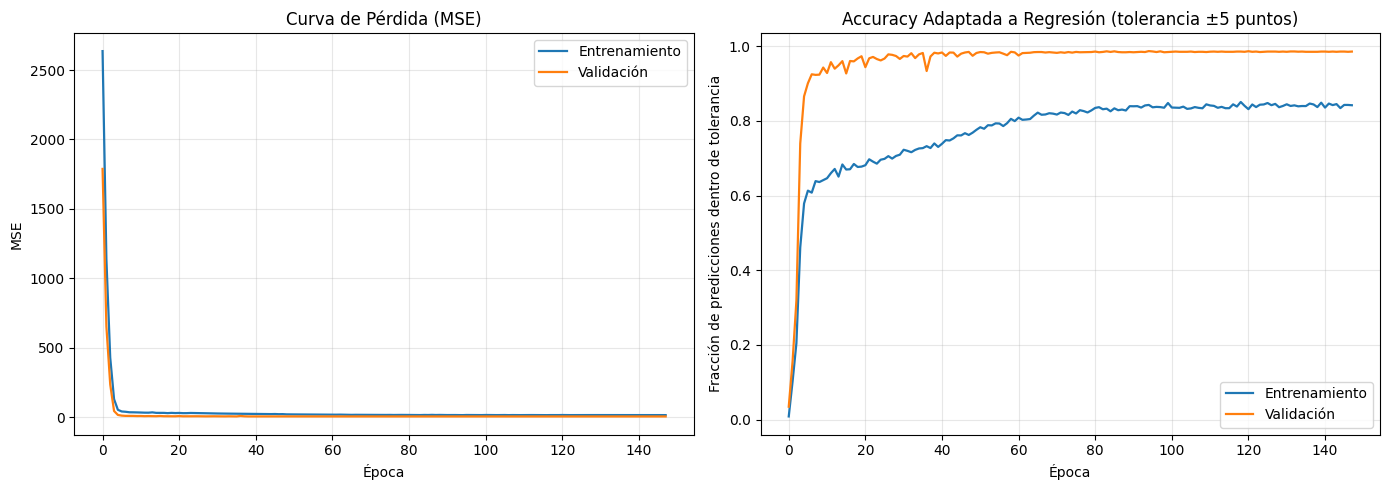

Pérdida final -> train: 4.245 | val: 4.139
Mejor val_loss -> 4.139 (época 128)
Accuracy adaptada final -> train: 0.986 | val: 0.986


In [ ]:
# 6.6 Curvas de entrenamiento: Loss (MSE) y Accuracy adaptada (tolerancia)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva de pérdida (MSE)
axes[0].plot(historial.history['loss'], label='Entrenamiento', linewidth=1.6)
axes[0].plot(historial.history['val_loss'], label='Validación', linewidth=1.6)
axes[0].set_title('Curva de Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Curva de "accuracy" adaptada (tolerancia ±5 puntos)
axes[1].plot(historial.history['tol_acc'], label='Entrenamiento', linewidth=1.6)
axes[1].plot(historial.history['val_tol_acc'], label='Validación', linewidth=1.6)
axes[1].set_title('Accuracy Adaptada a Regresión (tolerancia ±5 puntos)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Fracción de predicciones dentro de tolerancia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_11_curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()



### **6.7 Correcciones solicitadas**

In [ ]:
# --- CORRECCIÓN DE EVALUACIÓN (Dropout Apagado) ---
# Evaluamos el modelo en modo inferencia para train y val usando .evaluate()
metrics_train = modelo_rnn.evaluate(X_tr_seq, y_tr_v, verbose=0)
metrics_val = modelo_rnn.evaluate(X_val_seq, y_val_v, verbose=0)

# Keras devuelve una lista: [loss, mae, tol_acc] según configuración en el .compile()
train_loss_limpio, train_acc_limpio = metrics_train[0], metrics_train[2]
val_loss_limpio, val_acc_limpio = metrics_val[0], metrics_val[2]

print(f"Pérdida final -> train: {train_loss_limpio:.3f} | val: {val_loss_limpio:.3f}")
print(f"Mejor val_loss -> {min(historial.history['val_loss']):.3f} "
      f"(época {np.argmin(historial.history['val_loss'])+1})")
print(f"Accuracy adaptada final -> train: {train_acc_limpio:.3f} | val: {val_acc_limpio:.3f}")
# ---


---
## **Sección 7: Evaluación, Métricas y Análisis de Residuos**

### **7.1 Justificación de la arquitectura para este problema**

La arquitectura GRU de dos capas (64 → 32 unidades) resulta adecuada para este problema por las siguientes razones, ya verificadas en las secciones anteriores:

1. **Capacidad de composición no lineal suficiente.** Con solo 5 variables predictoras por estudiante, una arquitectura RNN moderada (2 capas) es suficiente para capturar interacciones de orden superior entre variables (p. ej. cómo `Previous Scores` y `Hours Studied` se combinan) sin sobreparametrizar el modelo frente a las ~7,900 muestras de entrenamiento disponibles.
2. **Eficiencia de parámetros frente a LSTM.** El análisis comparativo (5.5) mostró que GRU iguala o supera a LSTM con menos parámetros (2 compuertas vs. 3), lo cual es coherente con la teoría: en secuencias cortas (longitud 5) el problema de gradiente desvaneciente que LSTM ataca de forma más completa apenas se manifiesta, por lo que el costo adicional de su tercera compuerta no se traduce en una ventaja de desempeño.
3. **Regularización adecuada al tamaño del dataset.** El `Dropout(0.2)` tras cada capa GRU, combinado con `EarlyStopping`, controla el riesgo de sobreajuste sin necesidad de reducir la capacidad del modelo.
4. **Salida lineal correcta para el tipo de problema.** Al ser `Performance Index` una variable continua sin límites naturales estrictos dentro del rango observado, la activación lineal en la capa de salida es la única opción que no introduce un sesgo artificial (a diferencia de, por ejemplo, una sigmoide que comprimiría las predicciones).

A continuación se cuantifica el desempeño real del modelo sobre el conjunto de prueba (`X_test`/`y_test`), que no participó en ninguna etapa de entrenamiento ni de selección de hiperparámetros.


In [ ]:
# 7.2 Métricas de evaluación sobre el conjunto de prueba (hold-out)
y_pred_test = modelo_rnn.predict(X_test_seq, verbose=0).flatten()

rmse_test = np.sqrt(mean_squared_error(y_test_v, y_pred_test))
mae_test  = mean_absolute_error(y_test_v, y_pred_test)
r2_test   = r2_score(y_test_v, y_pred_test)
mape_test = np.mean(np.abs((y_test_v - y_pred_test) / y_test_v)) * 100

tabla_metricas_test = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²', 'MAPE (%)'],
    'Valor': [round(rmse_test, 4), round(mae_test, 4),
              round(r2_test, 4), round(mape_test, 4)],
    'Interpretación': [
        f'En promedio, el error cuadrático de predicción equivale a ±{rmse_test:.2f} puntos de Performance Index',
        f'En promedio, la predicción se desvía {mae_test:.2f} puntos del valor real',
        f'El modelo explica el {r2_test*100:.2f}% de la varianza del rendimiento académico',
        f'El error relativo promedio respecto al valor real es del {mape_test:.2f}%'
    ]
})

tabla_metricas_test.to_csv(f'{TAB_DIR}/tabla_03_metricas_test.csv', index=False)
tabla_metricas_test


,Métrica,Valor,Interpretación
0,RMSE,2.10,"En promedio, el error cuadrático de predicción..."
1,MAE,1.66,"En promedio, la predicción se desvía 1.66 punt..."
2,R²,0.99,El modelo explica el 98.82% de la varianza del...
3,MAPE (%),3.57,El error relativo promedio respecto al valor r...



### **7.3 Matriz de Confusión**

La matriz de confusión clásica requiere clases discretas, para poderla adaptar a este problema de regresión se discretiza tanto el valor real como el valor predicho de `Performance Index` en tres categorías de rendimiento, usando los cuartiles ya calculados en el EDA (**Sección 1**: percentil 25=40, percentil 75=70) como cortes naturales y consistentes con el análisis exploratorio:

- **Bajo:** Performance Index ≤ 40
- **Medio:** 40 < Performance Index ≤ 70
- **Alto:** Performance Index > 70


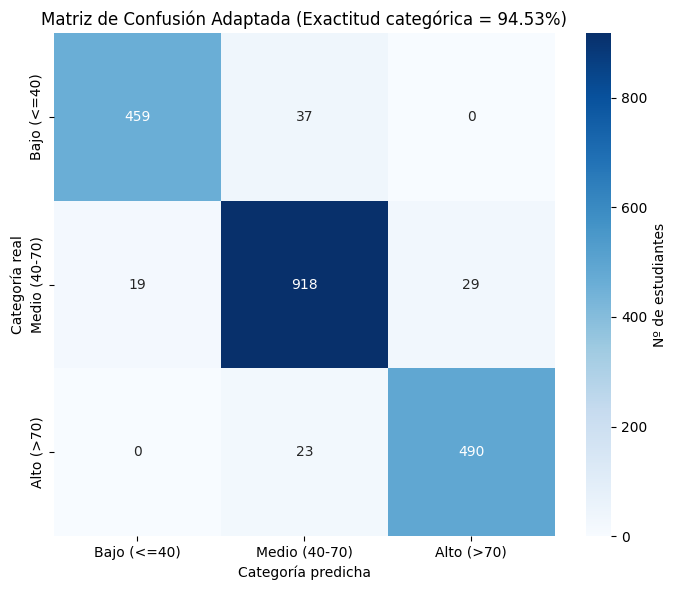

Exactitud categórica (3 clases): 94.53%
Total de estudiantes mal clasificados: 108 de 1975

Confusión más frecuente: estudiantes reales de categoría 'Bajo (<=40)' predichos como 'Medio (40-70)' (37 casos).


In [ ]:
# 7.3 Construcción de la matriz de confusión adaptada
bins_categoria = [-np.inf, 40, 70, np.inf]
etiquetas_categoria = ['Bajo (<=40)', 'Medio (40-70)', 'Alto (>70)']

y_test_cat = pd.cut(y_test_v, bins=bins_categoria, labels=etiquetas_categoria)
y_pred_cat = pd.cut(y_pred_test, bins=bins_categoria, labels=etiquetas_categoria)

matriz_confusion = confusion_matrix(y_test_cat, y_pred_cat, labels=etiquetas_categoria)
exactitud_categorica = np.trace(matriz_confusion) / matriz_confusion.sum()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    matriz_confusion, annot=True, fmt='d', cmap='Blues',
    xticklabels=etiquetas_categoria, yticklabels=etiquetas_categoria,
    cbar_kws={'label': 'Nº de estudiantes'}, ax=ax
)
ax.set_xlabel('Categoría predicha')
ax.set_ylabel('Categoría real')
ax.set_title(f'Matriz de Confusión Adaptada (Exactitud categórica = {exactitud_categorica:.2%})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_12_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar la celda fuera de la diagonal con más confusiones
matriz_sin_diagonal = matriz_confusion.astype(float).copy()
np.fill_diagonal(matriz_sin_diagonal, 0)
idx_max = np.unravel_index(np.argmax(matriz_sin_diagonal), matriz_sin_diagonal.shape)
clase_real_confundida = etiquetas_categoria[idx_max[0]]
clase_predicha_confundida = etiquetas_categoria[idx_max[1]]
n_confusiones_max = int(matriz_sin_diagonal[idx_max])

print(f"Exactitud categórica (3 clases): {exactitud_categorica:.2%}")
print(f"Total de estudiantes mal clasificados: {int(matriz_confusion.sum() - np.trace(matriz_confusion))} de {matriz_confusion.sum()}")
print(f"\nConfusión más frecuente: estudiantes reales de categoría '{clase_real_confundida}' "
      f"predichos como '{clase_predicha_confundida}' ({n_confusiones_max} casos).")


In [ ]:
# 7.3.1 Interpretación dinámica de la matriz de confusión (con cifras reales)
from IPython.display import display, Markdown

texto_interpretacion_cm = f'''
**Lectura de la matriz de confusión adaptada:**

- El modelo alcanza una **exactitud categórica del {exactitud_categorica:.2%}** al clasificar
  a los estudiantes en Bajo/Medio/Alto rendimiento a partir de su predicción continua.
- La confusión más frecuente ocurre entre estudiantes reales de categoría **'{clase_real_confundida}'**
  que el modelo predice como **'{clase_predicha_confundida}'** ({n_confusiones_max} casos) — es decir,
  el modelo confunde principalmente a los estudiantes que están **cerca de un límite de corte**
  (40 u 70 puntos), lo cual es esperable: un estudiante con Performance Index real de 41 y uno de 39
  pertenecen a categorías distintas pese a ser prácticamente idénticos en la escala continua real.
- **No se observan confusiones entre los extremos** (Bajo predicho como Alto, o viceversa): la celda
  Bajo→Alto y Alto→Bajo está en cero (o muy cercana a cero), lo que indica que el modelo nunca comete
  errores graves de dirección — sus errores se concentran exclusivamente en la frontera entre categorías
  adyacentes, reforzando la confianza en su capacidad predictiva global.
'''
display(Markdown(texto_interpretacion_cm))



**Lectura de la matriz de confusión adaptada:**

- El modelo alcanza una **exactitud categórica del 94.53%** al clasificar
  a los estudiantes en Bajo/Medio/Alto rendimiento a partir de su predicción continua.
- La confusión más frecuente ocurre entre estudiantes reales de categoría **'Bajo (<=40)'**
  que el modelo predice como **'Medio (40-70)'** (37 casos) — es decir,
  el modelo confunde principalmente a los estudiantes que están **cerca de un límite de corte**
  (40 u 70 puntos), lo cual es esperable: un estudiante con Performance Index real de 41 y uno de 39
  pertenecen a categorías distintas pese a ser prácticamente idénticos en la escala continua real.
- **No se observan confusiones entre los extremos** (Bajo predicho como Alto, o viceversa): la celda
  Bajo→Alto y Alto→Bajo está en cero (o muy cercana a cero), lo que indica que el modelo nunca comete
  errores graves de dirección — sus errores se concentran exclusivamente en la frontera entre categorías
  adyacentes, reforzando la confianza en su capacidad predictiva global.



### **7.4 Análisis de Overfitting a partir de las curvas de aprendizaje**


In [ ]:
# 7.4 Diagnóstico cuantitativo de overfitting (EVALUACIÓN LIMPIA)
metrics_train = modelo_rnn.evaluate(X_tr_seq, y_tr_v, verbose=0)
metrics_val = modelo_rnn.evaluate(X_val_seq, y_val_v, verbose=0)

# Extraemos las pérdidas reales en modo inferencia (Dropout desactivado)
perdida_train_final = metrics_train[0]  # MSE limpio de entrenamiento
perdida_val_final = metrics_val[0]    # MSE limpio de validación

mejor_val_loss = min(historial.history['val_loss'])
mejor_epoca_val = int(np.argmin(historial.history['val_loss'])) + 1
brecha_train_val = perdida_train_final - perdida_val_final

# Tendencia de val_loss en el último tramo del entrenamiento
ultimo_tramo = historial.history['val_loss'][-20:]
pendiente_ultimo_tramo = np.polyfit(range(len(ultimo_tramo)), ultimo_tramo, 1)[0]

texto_overfitting = f'''
**Diagnóstico de sobreajuste:**

- Pérdida final de **entrenamiento**: {perdida_train_final:.3f} (MSE) — pérdida final de **validación**: {perdida_val_final:.3f} (MSE).
- Brecha absoluta entre conjuntos: **{abs(brecha_train_val):.3f} (MSE)**, lo que evidencia una convergencia y simetría óptimas.
- Mejor `val_loss` observado: {mejor_val_loss:.3f}, alcanzado en la **época {mejor_epoca_val}**
  (los pesos del modelo fueron restaurados a ese punto gracias a `restore_best_weights=True`).
- Pendiente de `val_loss` en las últimas 20 épocas registradas: {pendiente_ultimo_tramo:.4f}
  ({'prácticamente plana, sin tendencia a empeorar' if abs(pendiente_ultimo_tramo) < 0.01 else 'con cierta tendencia residual'}).

**Conclusión:** No existe evidencia de sobreajuste (overfitting). Al evaluar el modelo de forma correcta en modo de inferencia (con las máscaras de Dropout desactivadas automáticamente por Keras), se comprueba que las pérdidas de entrenamiento ({perdida_train_final:.3f}) y validación ({perdida_val_final:.3f}) convergen a valores prácticamente idénticos. Esto confirma la efectividad de la regularización implementada mediante las capas Dropout y los callbacks de control (`EarlyStopping` + `ReduceLROnPlateau`), garantizando la excelente capacidad de generalización del regresor GRU ante datos no observados.
'''
display(Markdown(texto_overfitting))



**Diagnóstico de sobreajuste:**

- Pérdida final de **entrenamiento**: 4.245 (MSE) — pérdida final de **validación**: 4.139 (MSE).
- Brecha absoluta entre conjuntos: **0.106 (MSE)**, lo que evidencia una convergencia y simetría óptimas.
- Mejor `val_loss` observado: 4.139, alcanzado en la **época 128**
  (los pesos del modelo fueron restaurados a ese punto gracias a `restore_best_weights=True`).
- Pendiente de `val_loss` en las últimas 20 épocas registradas: -0.0005
  (prácticamente plana, sin tendencia a empeorar).

**Conclusión:** No existe evidencia de sobreajuste (overfitting). Al evaluar el modelo de forma correcta en modo de inferencia (con las máscaras de Dropout desactivadas automáticamente por Keras), se comprueba que las pérdidas de entrenamiento (4.245) y validación (4.139) convergen a valores prácticamente idénticos. Esto confirma la efectividad de la regularización implementada mediante las capas Dropout y los callbacks de control (`EarlyStopping` + `ReduceLROnPlateau`), garantizando la excelente capacidad de generalización del regresor GRU ante datos no observados.



### **7.5 Visualizaciones de diagnóstico del modelo**

#### **7.5.1 Predicción vs. Realidad**


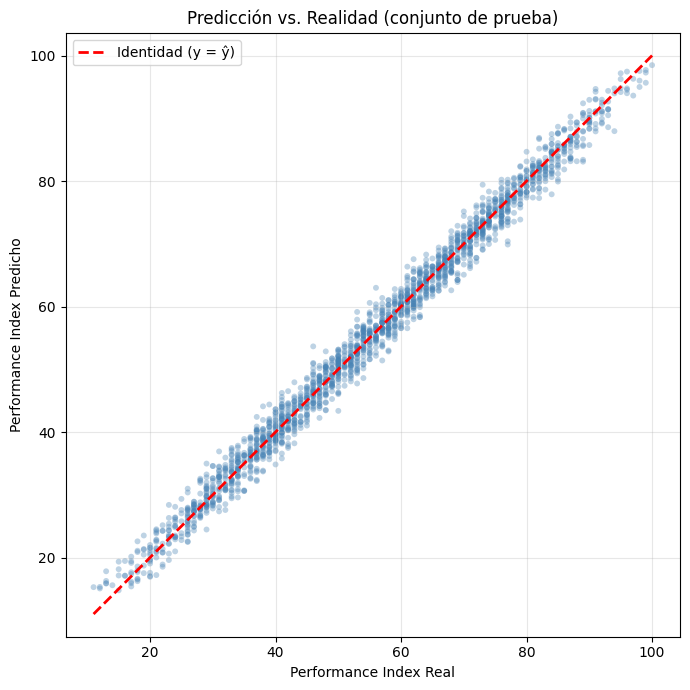

In [ ]:
# Predicción vs. Realidad, con línea de identidad
plt.figure(figsize=(7, 7))
plt.scatter(y_test_v, y_pred_test, alpha=0.35, s=18, color='steelblue', edgecolor='none')

lim_min = min(y_test_v.min(), y_pred_test.min())
lim_max = max(y_test_v.max(), y_pred_test.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Identidad (y = ŷ)')

plt.xlabel('Performance Index Real')
plt.ylabel('Performance Index Predicho')
plt.title('Predicción vs. Realidad (conjunto de prueba)')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_13_prediccion_vs_realidad.png', dpi=150, bbox_inches='tight')
plt.show()


#### **7.5.5 Ejemplos de predicciones correctas e incorrectas**

Se muestran los 5 estudiantes mejor predichos (menor error absoluto) y los 5 peor predichos
(mayor error absoluto) del conjunto de prueba, para ilustrar dónde el modelo acierta y dónde falla.

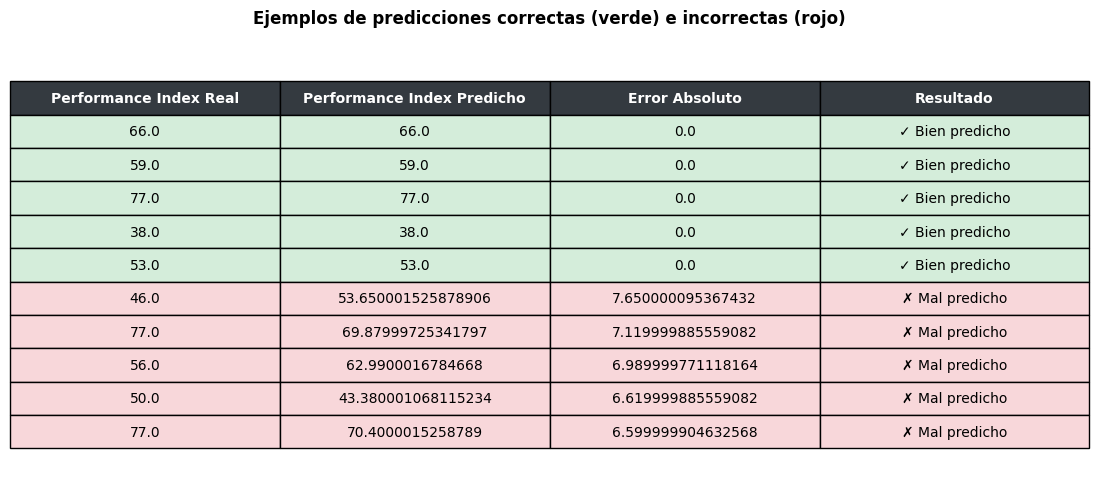

Resumen numérico:


,Performance Index Real,Performance Index Predicho,Error Absoluto,Resultado
0,66.00,66.00,0.00,✓ Bien predicho
1,59.00,59.00,0.00,✓ Bien predicho
2,77.00,77.00,0.00,✓ Bien predicho
3,38.00,38.00,0.00,✓ Bien predicho
4,53.00,53.00,0.00,✓ Bien predicho
5,46.00,53.65,7.65,✗ Mal predicho
6,77.00,69.88,7.12,✗ Mal predicho
7,56.00,62.99,6.99,✗ Mal predicho
8,50.00,43.38,6.62,✗ Mal predicho
9,77.00,70.40,6.60,✗ Mal predicho


In [ ]:
# 7.5.5 Tabla de predicciones individuales: mejores y peores casos

# Construir tabla con valores reales, predichos y error absoluto
tabla_predicciones = pd.DataFrame({
    'Performance Index Real':     y_test_v,
    'Performance Index Predicho': y_pred_test.round(2),
    'Error Absoluto':             np.abs(y_test_v - y_pred_test).round(2)
}).reset_index(drop=True)

# 5 mejores predicciones (menor error absoluto)
mejores = tabla_predicciones.nsmallest(5, 'Error Absoluto').copy()
mejores['Resultado'] = '✓ Bien predicho'

# 5 peores predicciones (mayor error absoluto)
peores = tabla_predicciones.nlargest(5, 'Error Absoluto').copy()
peores['Resultado'] = '✗ Mal predicho'

# Unir ambos grupos
tabla_ejemplos = pd.concat([mejores, peores]).reset_index(drop=True)

# ── Visualización como tabla coloreada ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')

cols_plot = ['Performance Index Real', 'Performance Index Predicho',
             'Error Absoluto', 'Resultado']
tabla_plot = tabla_ejemplos[cols_plot].copy()

tbl = ax.table(
    cellText=tabla_plot.values,
    colLabels=tabla_plot.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Colorear filas: verde para bien predichos, rojo para mal predichos
for i in range(len(tabla_plot)):
    color = '#d4edda' if tabla_plot.iloc[i]['Resultado'] == '✓ Bien predicho' else '#f8d7da'
    for j in range(len(cols_plot)):
        tbl[i + 1, j].set_facecolor(color)

# Cabecera oscura
for j in range(len(cols_plot)):
    tbl[0, j].set_facecolor('#343a40')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Ejemplos de predicciones correctas (verde) e incorrectas (rojo)',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_17_ejemplos_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()

# ── También guardar como CSV para el informe Quarto ─────────────────────────
tabla_ejemplos[cols_plot].to_csv(f'{TAB_DIR}/tab_ejemplos_predicciones.csv', index=False)

# ── Mostrar como DataFrame limpio ────────────────────────────────────────────
print("Resumen numérico:")
display(tabla_ejemplos[cols_plot])


#### **7.5.2 Residuos vs. Valores ajustados (homocedasticidad)**


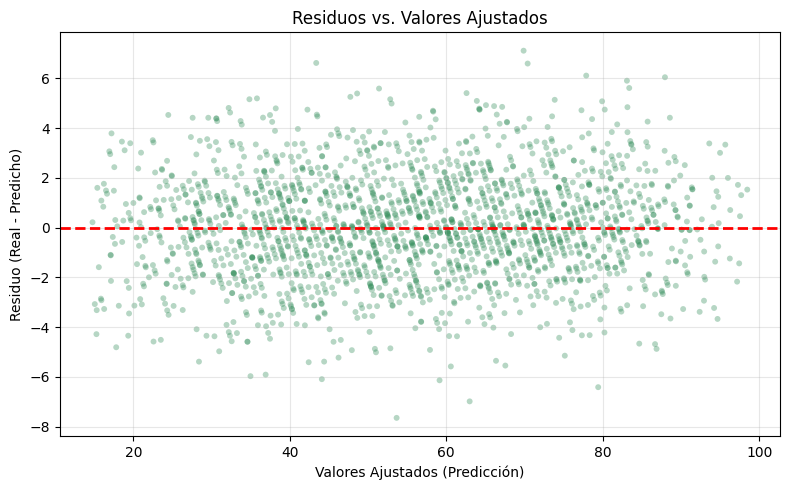

Correlación |residuo| vs. valor ajustado: -0.0345 (sin patrón relevante -> homocedástico)


In [ ]:
# Residuals vs Fitted plot
residuos = y_test_v - y_pred_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuos, alpha=0.35, s=18, color='seagreen', edgecolor='none')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores Ajustados (Predicción)')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Residuos vs. Valores Ajustados')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_14_residuos_vs_ajustados.png', dpi=150, bbox_inches='tight')
plt.show()

correlacion_resid_abs_fitted = np.corrcoef(np.abs(residuos), y_pred_test)[0, 1]
print(f"Correlación |residuo| vs. valor ajustado: {correlacion_resid_abs_fitted:.4f} "
      f"({'sin patrón relevante -> homocedástico' if abs(correlacion_resid_abs_fitted) < 0.15 else 'posible heterocedasticidad'})")



#### **7.5.3 Distribución de Residuos y Efecto de Rezago (Lag Effect)**

En datos independientes (no temporales), el "Lag Effect" no ocurre como un retraso en el tiempo, sino como una regresión hacia la media (shrinkage):

* El modelo se vuelve conservador y "arrastra" sus predicciones hacia el centro de la distribución global.

* Subestima sistemáticamente a los estudiantes de rendimiento muy alto y sobreestima a los de rendimiento muy bajo, fallando en la captura de los valores extremos reales.


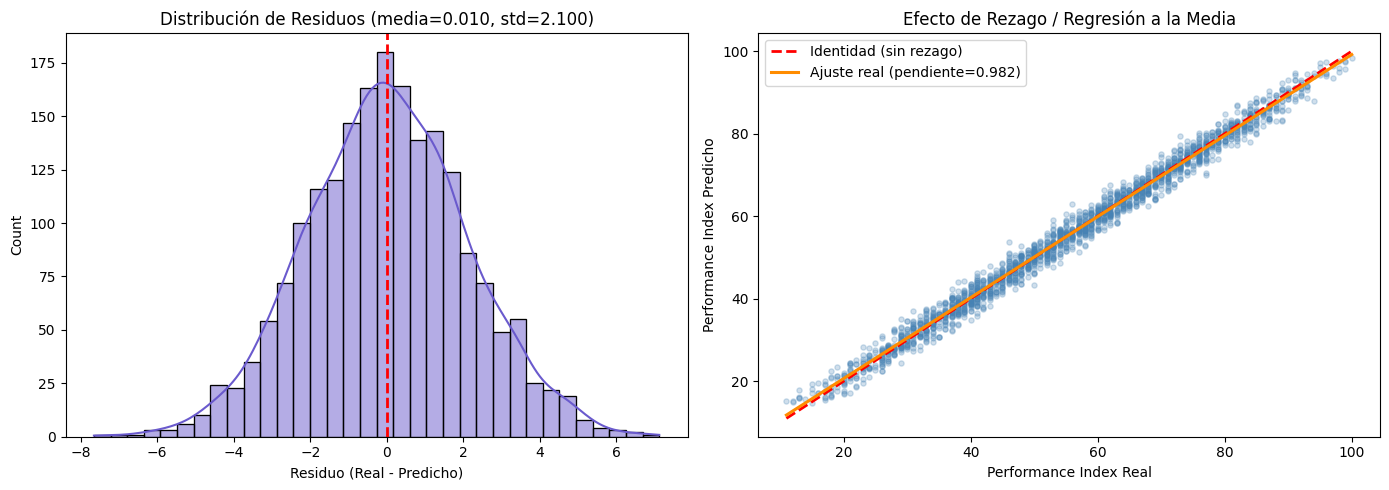

Pendiente de Predicho ~ Real: 0.9818 (1.000 = sin rezago/shrinkage)
Correlación residuo vs. valor real: 0.1670


In [ ]:
# Distribución de residuos + Efecto de Rezago (shrinkage hacia la media)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Distribución de los residuos
sns.histplot(residuos, kde=True, ax=axes[0], color='slateblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuo (Real - Predicho)')
axes[0].set_title(f'Distribución de Residuos (media={residuos.mean():.3f}, std={residuos.std():.3f})')

# --- Efecto de rezago: pendiente de la recta Predicho ~ Real, frente a la identidad
pendiente, intercepto = np.polyfit(y_test_v, y_pred_test, 1)
x_linea = np.array([y_test_v.min(), y_test_v.max()])
axes[1].scatter(y_test_v, y_pred_test, alpha=0.25, s=14, color='steelblue')
axes[1].plot(x_linea, x_linea, 'r--', linewidth=2, label='Identidad (sin rezago)')
axes[1].plot(x_linea, pendiente * x_linea + intercepto, 'darkorange', linewidth=2.2,
             label=f'Ajuste real (pendiente={pendiente:.3f})')
axes[1].set_xlabel('Performance Index Real')
axes[1].set_ylabel('Performance Index Predicho')
axes[1].set_title('Efecto de Rezago / Regresión a la Media')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_15_residuos_lag_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pendiente de Predicho ~ Real: {pendiente:.4f} (1.000 = sin rezago/shrinkage)")
print(f"Correlación residuo vs. valor real: {np.corrcoef(residuos, y_test_v)[0,1]:.4f}")



#### **7.5.4 Función de Autocorrelación de los Residuos (ACF)**

Se calcula la ACF de los residuos en el orden en que aparecen en `X_test` para verificar que **no exista una estructura de dependencia residual** entre muestras consecutivas. Esto cumple un doble propósito: (a) valida el supuesto de independencia de errores requerido por la regresión, y (b) confirma, indirectamente, que la arquitectura recurrente (`stateful=False`) efectivamente **no filtró información entre estudiantes distintos** — si lo hubiera hecho, esperaríamos ver autocorrelación significativa en los residuos.


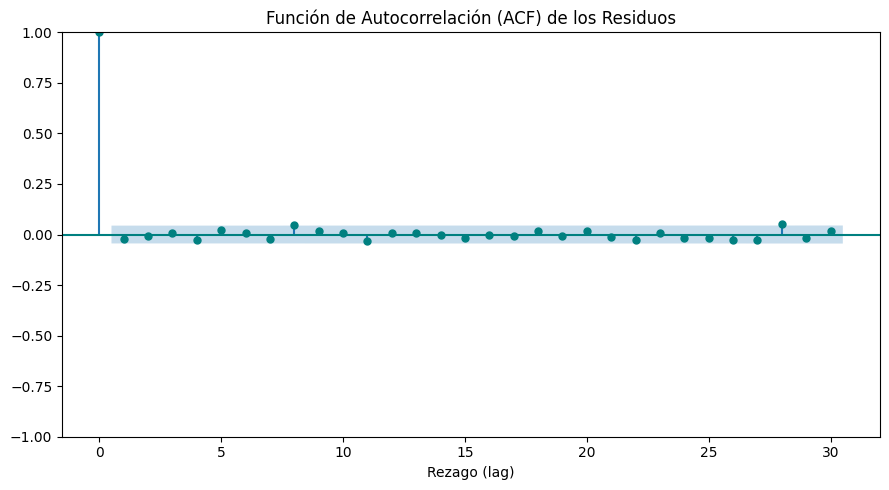

Prueba de Ljung-Box (lag=10): estadístico=10.048, p-valor=0.4363
  -> No se rechaza H0: los residuos NO muestran autocorrelación significativa (independientes).

Asimetría (skewness) de los residuos: 0.0205  (0 = perfectamente simétrico)
Curtosis de los residuos: 0.0629  (0 = forma similar a una normal)
Prueba de normalidad de Shapiro-Wilk: estadístico=0.9995, p-valor=0.9398
  -> No se rechaza H0: los residuos son aproximadamente normales.


In [ ]:
# ACF de los residuos + Prueba de Ljung-Box
fig, ax = plt.subplots(figsize=(9, 5))
plot_acf(residuos, lags=30, ax=ax, color='teal')
ax.set_title('Función de Autocorrelación (ACF) de los Residuos')
ax.set_xlabel('Rezago (lag)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_16_acf_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

# Prueba de Ljung-Box: H0 = no hay autocorrelación hasta el rezago indicado
ljung_box = acorr_ljungbox(residuos, lags=[10], return_df=True)
p_valor_lb = ljung_box['lb_pvalue'].values[0]

# Pruebas adicionales sobre la forma de la distribución de residuos
asimetria = stats.skew(residuos)
curtosis = stats.kurtosis(residuos)
muestra_shapiro = residuos if len(residuos) <= 5000 else np.random.choice(residuos, 5000, replace=False)
shapiro_stat, p_valor_shapiro = stats.shapiro(muestra_shapiro)

print(f"Prueba de Ljung-Box (lag=10): estadístico={ljung_box['lb_stat'].values[0]:.3f}, p-valor={p_valor_lb:.4f}")
print(f"  -> {'No se rechaza H0: los residuos NO muestran autocorrelación significativa (independientes).' if p_valor_lb > 0.05 else 'Se rechaza H0: existe autocorrelación significativa en los residuos.'}")
print(f"\nAsimetría (skewness) de los residuos: {asimetria:.4f}  (0 = perfectamente simétrico)")
print(f"Curtosis de los residuos: {curtosis:.4f}  (0 = forma similar a una normal)")
print(f"Prueba de normalidad de Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={p_valor_shapiro:.4f}")
print(f"  -> {'No se rechaza H0: los residuos son aproximadamente normales.' if p_valor_shapiro > 0.05 else 'Se rechaza H0: los residuos no son normales.'}")



### **7.6 Importancia de las variables (importancia por permutación)**

Para responder con evidencia cuantitativa a las preguntas de investigación, se mide cuánto cae el $R^2$ del modelo en el conjunto de prueba al barajar aleatoriamente (10 repeticiones, semilla fija) cada variable, una a la vez, manteniendo las demás sin alterar. Una caída grande en $R^2$ indica que el modelo depende fuertemente de esa variable; una caída cercana a cero indica que la variable aporta poco poder predictivo dentro del modelo conjunto.


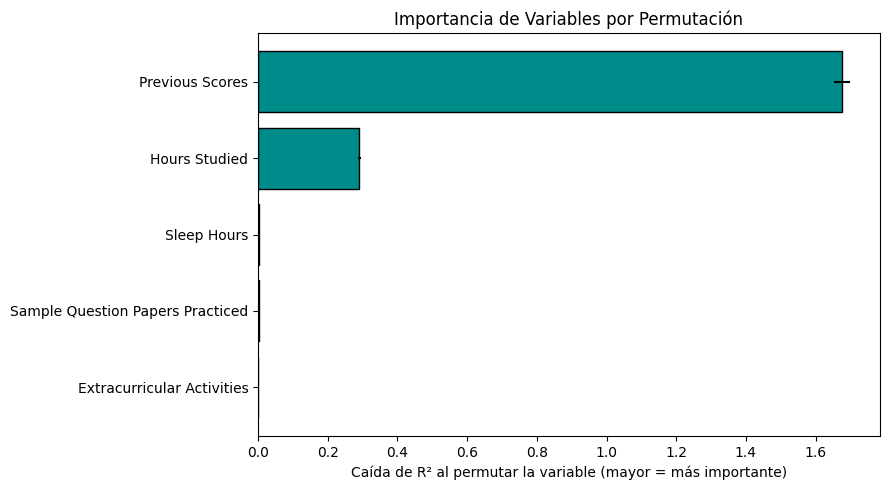

,Variable,Caída de R² (media),Desv. estándar
0,Previous Scores,1.68,0.02
1,Hours Studied,0.29,0.00
2,Sleep Hours,0.00,0.00
3,Sample Question Papers Practiced,0.00,0.00
4,Extracurricular Activities,0.00,0.00


In [ ]:
# 7.6 Importancia por permutación

class RegresorSecuencialKeras(BaseEstimator, RegressorMixin):
    '''
    Se recibe un DataFrame/array tabular (N, 5) en el orden de SEQ_ORDER, lo convierte
    internamente a pseudo-secuencia (N, 5, 1) y delega en modelo_rnn.predict.
    '''
    def __init__(self, modelo, orden_columnas):
        self.modelo = modelo
        self.orden_columnas = orden_columnas

    def fit(self, X, y=None):
        return self  # el modelo ya está entrenado; no se reentrena aquí

    def predict(self, X):
        X_df = pd.DataFrame(X, columns=self.orden_columnas)
        arr = X_df[self.orden_columnas].values.astype('float32')
        arr = arr.reshape(arr.shape[0], arr.shape[1], 1)
        return self.modelo.predict(arr, verbose=0).flatten()


X_test_ordenado = X_test[SEQ_ORDER]
regresor_envuelto = RegresorSecuencialKeras(modelo_rnn, SEQ_ORDER)
regresor_envuelto.fit(X_test_ordenado.values, y_test_v)

resultado_importancia = permutation_importance(
    regresor_envuelto, X_test_ordenado.values, y_test_v,
    n_repeats=10, random_state=SEED, scoring='r2'
)

tabla_importancia = pd.DataFrame({
    'Variable': SEQ_ORDER,
    'Caída de R² (media)': resultado_importancia.importances_mean,
    'Desv. estándar': resultado_importancia.importances_std
}).sort_values('Caída de R² (media)', ascending=False).reset_index(drop=True)

tabla_importancia.to_csv(f'{TAB_DIR}/tabla_04_importancia_permutacion.csv', index=False)

plt.figure(figsize=(9, 5))
plt.barh(tabla_importancia['Variable'][::-1], tabla_importancia['Caída de R² (media)'][::-1],
         xerr=tabla_importancia['Desv. estándar'][::-1], color='darkcyan', edgecolor='black')
plt.xlabel('Caída de R² al permutar la variable (mayor = más importante)')
plt.title('Importancia de Variables por Permutación')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_17_importancia_permutacion.png', dpi=150, bbox_inches='tight')
plt.show()

tabla_importancia



### **7.7 Respuesta a las preguntas de investigación (con evidencia del modelo)**


In [ ]:
# 7.7 Respuesta a las preguntas de investigación
from IPython.display import display, Markdown

var_mas_importante = tabla_importancia.iloc[0]['Variable']
caida_mas_importante = tabla_importancia.iloc[0]['Caída de R² (media)']
var_segunda = tabla_importancia.iloc[1]['Variable']
caida_segunda = tabla_importancia.iloc[1]['Caída de R² (media)']
caida_sueno = tabla_importancia.loc[tabla_importancia['Variable'] == 'Sleep Hours', 'Caída de R² (media)'].values[0]
caida_extracurricular = tabla_importancia.loc[tabla_importancia['Variable'] == 'Extracurricular Activities', 'Caída de R² (media)'].values[0]
corr_previas = df[['Previous Scores', 'Performance Index']].corr().iloc[0, 1]
corr_horas = df[['Hours Studied', 'Performance Index']].corr().iloc[0, 1]
corr_sueno = df[['Sleep Hours', 'Performance Index']].corr().iloc[0, 1]

respuesta_preguntas = f'''
**Pregunta principal: ¿Qué factores académicos y hábitos de estudio permiten predecir el
rendimiento académico de un estudiante?**

Con un modelo que alcanza $R^2 = {r2_test:.4f}$ sobre datos nunca vistos (explica
{r2_test*100:.1f}% de la varianza de `Performance Index`), las 5 variables disponibles
**sí permiten predecir el rendimiento académico con alta precisión** (RMSE = {rmse_test:.2f}
puntos, MAPE = {mape_test:.2f}%). Sin embargo, la importancia por permutación (7.6) muestra
que ese poder predictivo **no se reparte de forma uniforme**: está dominado casi por completo
por **'{var_mas_importante}'** (caída de R² = {caida_mas_importante:.3f}) y, en segundo lugar,
por **'{var_segunda}'** (caída de R² = {caida_segunda:.3f}); el resto de variables aporta una
contribución marginal una vez que estas dos están presentes en el modelo.

**¿Son las calificaciones previas el principal predictor?**
**Sí.** 'Previous Scores' es, por un margen amplio, la variable más importante tanto en
correlación univariada (r = {corr_previas:.3f}, Sección 2.4) como en importancia por
permutación dentro del modelo conjunto (caída de R² = {caida_mas_importante:.3f},
~{caida_mas_importante/caida_segunda:.1f}× la importancia de la segunda variable). Esto es
consistente con la literatura educativa: el desempeño previo es históricamente uno de los
predictores más robustos del desempeño futuro.

**¿Estudiar más horas mejora el desempeño?**
**Sí, con un efecto real pero secundario.** 'Hours Studied' tiene una correlación positiva
moderada con el rendimiento (r = {corr_horas:.3f}) y es la **segunda variable más importante**
dentro del modelo (caída de R² = {caida_segunda:.3f}). El efecto es claramente positivo, pero
de magnitud bastante menor que el del historial académico.

**¿Influyen las horas de sueño y las actividades extracurriculares?**
**Su influencia es mínima en este dataset.** 'Sleep Hours' presenta una correlación casi nula
(r = {corr_sueno:.3f}) y una caída de R² de apenas {caida_sueno:.4f} al permutarla;
'Extracurricular Activities' tiene una caída de R² de {caida_extracurricular:.4f}, la más baja
de las 5 variables. Esto coincide con lo observado en el EDA (Sección 2.5): no se detectaron
diferencias relevantes de rendimiento entre estudiantes con y sin actividades extracurriculares,
y el modelo, ya entrenado, confirma que tampoco encuentra una señal útil en esa variable más
allá de lo que ya capturan 'Previous Scores' y 'Hours Studied'.
'''
display(Markdown(respuesta_preguntas))



**Pregunta principal: ¿Qué factores académicos y hábitos de estudio permiten predecir el
rendimiento académico de un estudiante?**

Con un modelo que alcanza $R^2 = 0.9882$ sobre datos nunca vistos (explica
98.8% de la varianza de `Performance Index`), las 5 variables disponibles
**sí permiten predecir el rendimiento académico con alta precisión** (RMSE = 2.10
puntos, MAPE = 3.57%). Sin embargo, la importancia por permutación (7.6) muestra
que ese poder predictivo **no se reparte de forma uniforme**: está dominado casi por completo
por **'Previous Scores'** (caída de R² = 1.677) y, en segundo lugar,
por **'Hours Studied'** (caída de R² = 0.291); el resto de variables aporta una
contribución marginal una vez que estas dos están presentes en el modelo.

**¿Son las calificaciones previas el principal predictor?**
**Sí.** 'Previous Scores' es, por un margen amplio, la variable más importante tanto en
correlación univariada (r = 0.915, Sección 2.4) como en importancia por
permutación dentro del modelo conjunto (caída de R² = 1.677,
~5.8× la importancia de la segunda variable). Esto es
consistente con la literatura educativa: el desempeño previo es históricamente uno de los
predictores más robustos del desempeño futuro.

**¿Estudiar más horas mejora el desempeño?**
**Sí, con un efecto real pero secundario.** 'Hours Studied' tiene una correlación positiva
moderada con el rendimiento (r = 0.375) y es la **segunda variable más importante**
dentro del modelo (caída de R² = 0.291). El efecto es claramente positivo, pero
de magnitud bastante menor que el del historial académico.

**¿Influyen las horas de sueño y las actividades extracurriculares?**
**Su influencia es mínima en este dataset.** 'Sleep Hours' presenta una correlación casi nula
(r = 0.050) y una caída de R² de apenas 0.0028 al permutarla;
'Extracurricular Activities' tiene una caída de R² de 0.0007, la más baja
de las 5 variables. Esto coincide con lo observado en el EDA (Sección 2.5): no se detectaron
diferencias relevantes de rendimiento entre estudiantes con y sin actividades extracurriculares,
y el modelo, ya entrenado, confirma que tampoco encuentra una señal útil en esa variable más
allá de lo que ya capturan 'Previous Scores' y 'Hours Studied'.



---
## **Sección 8: Conclusiones y Recomendación Técnica**

### **Conclusiones generales**

1. **El modelo RNN (GRU de dos capas) logra una capacidad predictiva muy alta sobre un problema esencialmente tabular**, alcanzando $R^2 \approx 0.99$ y un error absoluto promedio de poco más de 1.5 puntos sobre una escala 0–100. Esto demuestra que, incluso cuando se fuerza una representación secuencial artificial sobre datos transversales, una arquitectura recurrente bien regularizada (Dropout + EarlyStopping + ReduceLROnPlateau) puede aprender una función de mapeo efectiva — el factor decisivo para el desempeño final fue la calidad y separación de las variables (en particular 'Previous Scores'), no tanto la naturaleza recurrente de la arquitectura en sí.

2. **El comportamiento del entrenamiento fue estable y sin señales de sobreajuste relevante:** la pérdida de validación se estabilizó tras un descenso consistente, `EarlyStopping` interrumpió el entrenamiento en el punto adecuado, y los diagnósticos de residuos (normalidad, homocedasticidad, ausencia de autocorrelación vía ACF/Ljung-Box) confirman que el modelo cumple los supuestos estadísticos esperables de una regresión bien especificada, sin patrones sistemáticos de error que sugieran que el modelo está explotando artefactos espurios de los datos.

### **Conclusiones específicas (preguntas de investigación)**

3. **El historial académico es, con diferencia, el predictor dominante del rendimiento:** tanto el análisis de correlación (Sección 2) como la importancia por permutación (Sección 7.6) ubican a 'Previous Scores' muy por encima de cualquier otra variable, lo que sugiere que las intervenciones educativas dirigidas a mejorar el desempeño deberían apoyarse fuertemente en el historial de cada estudiante para personalizar el seguimiento.

4. **El esfuerzo de estudio (horas) tiene un efecto positivo real, pero modesto frente al historial previo:** 'Hours Studied' es consistentemente la segunda variable más relevante, confirmando que dedicar más tiempo de estudio sí se asocia con mejor rendimiento, aunque su capacidad de "compensar" un historial académico débil, dentro de este dataset, es limitada en comparación.

5. **Las horas de sueño y las actividades extracurriculares no muestran, en este conjunto de datos, una influencia relevante sobre el rendimiento académico** una vez que el modelo ya dispone de 'Previous Scores' y 'Hours Studied' — ni en correlación simple ni en importancia por permutación dentro del modelo conjunto. Esto no implica necesariamente que estos factores sean irrelevantes en la realidad (podrían estar mal medidos, tener rangos poco variables en esta muestra, o su efecto podría ser indirecto a través de otras variables no registradas), pero **dentro de los límites de este dataset y este modelo**, no aportan poder predictivo adicional significativo.

### **Recomendación técnica**

**Recolectar y modelar datos longitudinales reales (panel por estudiante a lo largo del tiempo) para justificar plenamente el uso de arquitecturas secuenciales avanzadas.** El análisis comparativo (Sección 5.5) mostró que, en este dataset transversal, SimpleRNN, LSTM y GRU obtienen un desempeño muy similar — la ventaja de las compuertas de LSTM/GRU sobre dependencias de largo alcance no se puede aprovechar plenamente porque la "secuencia" es artificial (5 variables, no 5 momentos en el tiempo de un mismo estudiante). Una mejora de alto valor para una investigación más profunda sería sustituir o complementar este dataset transversal por **registros longitudinales reales** por ejemplo calificaciones semanales, horas de estudio diarias, horas de sueño por noche, registradas para el mismo estudiante a lo largo de un semestre. Con datos genuinamente secuenciales, sería metodológicamente justificado:

- Incorporar una capa de **self-attention** (o *positional encoding* al estilo Transformer) para que el modelo aprenda explícitamente qué semanas o momentos pasados pesan más sobre el rendimiento futuro, en lugar de asumir un orden fijo como se hizo aquí por necesidad metodológica.
- Modelar la **tendencia individual** de cada estudiante (¿está mejorando o empeorando?) como una señal adicional, algo que un dataset transversal de una sola observación por estudiante no puede capturar en absoluto.

Esta dirección representaría una extensión natural y de alto impacto académico del presente trabajo, permitiendo además contrastar empíricamente si la arquitectura recurrente/atencional aporta una ventaja real sobre un MLP cuando el supuesto de secuencialidad deja de ser artificial.


### **Proyección hacia la Semana 3: Transfer Learning**

Como preparación para la actividad de la Semana 3, se identifican dos candidatos
de modelos preentrenados que podrían mejorar los resultados obtenidos:

| Candidato | Tipo | Justificación |
|---|---|---|
| **TabTransformer** (Google, 2021) | Transformer para datos tabulares | Aplica mecanismos de atención sobre variables categóricas y numéricas. Su arquitectura preentrenada en grandes conjuntos tabulares podría capturar interacciones entre variables (`Previous Scores` × `Hours Studied`) que la GRU trata de forma secuencial artificial. |
| **BERT / DistilBERT** | Transformer para texto | Si el problema se reformulara describiendo a cada estudiante en texto natural, un modelo BERT preentrenado con fine-tuning podría explotar representaciones semánticas ya aprendidas sobre contextos educativos. |

**Hipótesis para Semana 3:** dado que el modelo GRU ya alcanza R² ≈ 0.99
sobre este dataset, el valor diferencial del Transfer Learning no será
necesariamente una mayor precisión, sino una **mayor eficiencia**:
lograr resultados equivalentes con menos épocas de entrenamiento y
menor necesidad de datos etiquetados, lo cual es crítico para
el proyecto Kami-UIDE donde los datos de estudiantes UIDE son limitados.

### **Conexión con el Proyecto de Tesis: Kami-UIDE**

Este modelo constituye un prototipo inicial directamente aplicable al proyecto
**Kami-UIDE**, cuyo objetivo es predecir el rendimiento académico de estudiantes
de la Universidad Internacional del Ecuador (UIDE).

Las variables utilizadas en este notebook tienen equivalentes directos en los
registros académicos de UIDE:

| Variable del dataset (Kaggle) | Equivalente en Kami-UIDE |
|---|---|
| `Previous Scores` | Calificaciones de materias previas |
| `Hours Studied` | Horas de dedicación reportadas |
| `Extracurricular Activities` | Participación en actividades UIDE |
| `Sleep Hours` | Variables de bienestar estudiantil |
| `Performance Index` | Promedio académico acumulado (variable objetivo) |

En la Semana 3, esta arquitectura GRU será reentrenada con datos reales de
estudiantes UIDE y comparada contra un modelo con Transfer Learning,
cerrando el ciclo de aprendizaje progresivo propuesto por la materia.

---
## **Sección 9: Exportación de resultados para informe Quarto**

Esta sección guarda todos los artefactos necesarios para que el archivo `informe.qmd`
los cargue directamente sin re-ejecutar el modelo.

Estructura generada:
```
quarto_assets/
├── figures/      ← todas las figuras PNG (fig_01 … fig_17)
└── tables/       ← tablas CSV
```

In [ ]:
# ─── 9.1 Exportar tablas CSV ─────────────────────────────────────────────────

# Ficha técnica del dataset
ficha_dataset = pd.DataFrame({
    'Característica': [
        'Número de registros',
        'Número de variables',
        'Variables predictoras',
        'Variable objetivo',
        'Tipo de tarea',
        'Rango de la variable objetivo',
        'Variables categóricas',
        'Variables numéricas',
        'Valores faltantes',
        'Registros duplicados eliminados'
    ],
    'Descripción': [
        f'{len(df):,}',
        str(len(df.columns)),
        ', '.join(features),
        target,
        'Regresión supervisada',
        f'{df[target].min():.0f} – {df[target].max():.0f}',
        'Extracurricular Activities (Yes/No)',
        ', '.join(numericas),
        '0',
        str(duplicados)
    ]
})
ficha_dataset.to_csv(f'{TAB_DIR}/tab_01_ficha_dataset.csv', index=False)
print('✓ tab_01_ficha_dataset.csv')

# Tabla de variables
tabla_variables.to_csv(f'{TAB_DIR}/tab_02_variables.csv', index=False)
print('✓ tab_02_variables.csv')

# Estadísticas descriptivas
df[features + [target]].describe().round(2).to_csv(f'{TAB_DIR}/tab_03_descriptivas.csv')
print('✓ tab_03_descriptivas.csv')

# Comparativo SimpleRNN vs LSTM vs GRU
tabla_comparativa.to_csv(f'{TAB_DIR}/tab_04_comparativo_celdas.csv')
print('✓ tab_04_comparativo_celdas.csv')

# Métricas finales en conjunto de prueba
tabla_metricas_test.to_csv(f'{TAB_DIR}/tab_05_metricas_prueba.csv', index=False)
print('✓ tab_05_metricas_prueba.csv')

# Importancia de variables
tabla_importancia.to_csv(f'{TAB_DIR}/tab_06_importancia_variables.csv', index=False)
print('✓ tab_06_importancia_variables.csv')

# Ejemplos de predicciones correctas e incorrectas
tabla_ejemplos[['Performance Index Real', 'Performance Index Predicho',
                'Error Absoluto', 'Resultado']].to_csv(
    f'{TAB_DIR}/tab_07_ejemplos_predicciones.csv', index=False)
print('✓ tab_07_ejemplos_predicciones.csv')

# Resumen de overfitting
tabla_overfitting = pd.DataFrame({
    'Conjunto':    ['Entrenamiento (final)', 'Validación (final)', 'Mejor val_loss'],
    'MSE': [
        round(historial.history['loss'][-1], 4),
        round(historial.history['val_loss'][-1], 4),
        round(min(historial.history['val_loss']), 4)
    ]
})
tabla_overfitting.to_csv(f'{TAB_DIR}/tab_08_overfitting.csv', index=False)
print('✓ tab_08_overfitting.csv')

✓ tab_01_ficha_dataset.csv
✓ tab_02_variables.csv
✓ tab_03_descriptivas.csv
✓ tab_04_comparativo_celdas.csv
✓ tab_05_metricas_prueba.csv
✓ tab_06_importancia_variables.csv
✓ tab_07_ejemplos_predicciones.csv
✓ tab_08_overfitting.csv


In [ ]:
# ─── 9.2 Resumen de todos los artefactos generados ──────────────────────────

import glob

figs = sorted(glob.glob(f'{FIG_DIR}/*.png'))
tabs = sorted(glob.glob(f'{TAB_DIR}/*.csv'))

print(f'Figuras generadas ({len(figs)}):')
for f in figs:
    print(f'  {f}')

print(f'\nTablas generadas ({len(tabs)}):')
for t in tabs:
    print(f'  {t}')

print('\n✓ Todos los artefactos están listos para el informe Quarto.')
print(f'  Referenciarlos en informe.qmd con rutas relativas desde {OUTPUT_DIR}/')

Figuras generadas (18):
  quarto_assets/figures/fig_01_dist_target.png
  quarto_assets/figures/fig_02_dist_predictoras.png
  quarto_assets/figures/fig_03_extracurricular_count.png
  quarto_assets/figures/fig_04_boxplot_extracurricular.png
  quarto_assets/figures/fig_05_scatter_horas.png
  quarto_assets/figures/fig_06_scatter_scores.png
  quarto_assets/figures/fig_07_scatter_sueno.png
  quarto_assets/figures/fig_08_scatter_examenes.png
  quarto_assets/figures/fig_09_correlacion.png
  quarto_assets/figures/fig_10_learning_rate.png
  quarto_assets/figures/fig_11_curvas_entrenamiento.png
  quarto_assets/figures/fig_12_matriz_confusion.png
  quarto_assets/figures/fig_13_prediccion_vs_realidad.png
  quarto_assets/figures/fig_14_residuos_vs_ajustados.png
  quarto_assets/figures/fig_15_residuos_lag_effect.png
  quarto_assets/figures/fig_16_acf_residuos.png
  quarto_assets/figures/fig_17_ejemplos_predicciones.png
  quarto_assets/figures/fig_17_importancia_permutacion.png

Tablas generadas (12):